Assignment : Object Tracking

Object Tracking

In [ ]:
1. What is object tracking, and how does it differ from object detection?

Object Tracking is the task of locating a specific object or multiple objects in a video stream over time — that is, you first detect an object in one frame, and then you keep following its position in each subsequent frame.

Example:

Tracking a football during a match broadcast.

Tracking a person moving through security camera footage.

The main goal is to estimate the trajectory of the object(s) across frames.

✅ 2. What is Object Detection?
Object Detection is the task of identifying and localizing objects within a single image (or frame) — that means you answer:

What objects are present? (Classification)

Where are they? (Bounding boxes or masks)

Example:

Detecting all cars, people, and traffic lights in a street scene.

✅ 3. Key Difference
Aspect	Object Detection	Object Tracking
Input	Single image/frame	Sequence of frames (video)
Output	Classes & locations (bounding boxes or masks) for each frame independently	Object identities + trajectories over time
Goal	Find objects & their locations	Maintain consistent IDs and follow objects’ movement
Typical Use	Static scene analysis, counting	Action recognition, video surveillance, behavior analysis

✅ 4. How They Work Together
Detection + Tracking Pipeline:
Many practical tracking systems first run an object detector on each frame to detect objects, then use a tracker (e.g., Kalman Filter, SORT, DeepSORT, optical flow) to associate detections over time and assign consistent IDs.

Why Not Detect Every Frame?
Detection is computationally expensive and can fail with occlusion or motion blur — tracking helps maintain identity when detection is unreliable.

📌 Summary
Concept	What it does
Object Detection	Finds what and where (per frame).
Object Tracking	Keeps track of the same object(s) over time.


In [ ]:
2. Explain the basic working principle of a Kalman Filter?

A Kalman Filter is an optimal recursive algorithm used to estimate the state of a dynamic system (like position and velocity) from noisy or incomplete measurements.

It’s widely used for tracking because it can:

Predict where an object should be.

Correct that prediction using noisy measurements.

Do this recursively in real-time.

✅ Core Idea
The Kalman Filter works in two main steps for each time step:

Prediction

Predict the current state based on the previous state and a motion model.

Predict the uncertainty (covariance) in the prediction.

Update (Correction)

Take a new measurement.

Compare the measurement to the prediction.

Correct the prediction by blending it with the measurement — giving more weight to whichever is more trustworthy (based on uncertainty).

✅ Example Intuition
Let’s say you want to track the position of a car:

You know the car’s last position & velocity.

You predict where it should be now: position_new = position_old + velocity * time.

You take a noisy GPS measurement.

The filter blends the predicted position and the GPS measurement, giving you an improved estimate.

✅ Key Steps Mathematically
1️⃣ Predict:

Predicted State:

𝑥
^
𝑘
∣
𝑘
−
1
=
𝐴
𝑥
^
𝑘
−
1
∣
𝑘
−
1
+
𝐵
𝑢
𝑘
x
^
  
k∣k−1
​
 =A 
x
^
  
k−1∣k−1
​
 +Bu 
k
​
 
𝐴
A: State transition model (e.g., constant velocity).

𝐵
𝑢
𝑘
Bu 
k
​
 : Optional control input.

Predicted Covariance:

𝑃
𝑘
∣
𝑘
−
1
=
𝐴
𝑃
𝑘
−
1
∣
𝑘
−
1
𝐴
𝑇
+
𝑄
P 
k∣k−1
​
 =AP 
k−1∣k−1
​
 A 
T
 +Q
𝑄
Q: Process noise (uncertainty in motion).

2️⃣ Update:

Compute Kalman Gain:

𝐾
𝑘
=
𝑃
𝑘
∣
𝑘
−
1
𝐻
𝑇
(
𝐻
𝑃
𝑘
∣
𝑘
−
1
𝐻
𝑇
+
𝑅
)
−
1
K 
k
​
 =P 
k∣k−1
​
 H 
T
 (HP 
k∣k−1
​
 H 
T
 +R) 
−1
 
𝐻
H: Measurement model.

𝑅
R: Measurement noise.

Update State Estimate:

𝑥
^
𝑘
∣
𝑘
=
𝑥
^
𝑘
∣
𝑘
−
1
+
𝐾
𝑘
(
𝑧
𝑘
−
𝐻
𝑥
^
𝑘
∣
𝑘
−
1
)
x
^
  
k∣k
​
 = 
x
^
  
k∣k−1
​
 +K 
k
​
 (z 
k
​
 −H 
x
^
  
k∣k−1
​
 )
Update Covariance:

𝑃
𝑘
∣
𝑘
=
(
𝐼
−
𝐾
𝑘
𝐻
)
𝑃
𝑘
∣
𝑘
−
1
P 
k∣k
​
 =(I−K 
k
​
 H)P 
k∣k−1
​
 
✅ Why Is It Powerful?
✔️ Combines predictions & measurements in an optimal way (minimum mean square error)
✔️ Handles noisy data robustly
✔️ Works recursively in real time
✔️ Simple & efficient for linear systems with Gaussian noise

✅ Where It’s Used
Object tracking in videos.

GPS & IMU sensor fusion.

Robotics & autonomous vehicles.

Finance & economics.

✅ Summary Diagram
🔍 Think of it like this:
Prediction: Where should it be?
Measurement: Where does my sensor say it is?
Update: Combine both based on trust.




In [ ]:
3. What is YOLO, and why is it popular for object detection in real-time application

YOLO stands for You Only Look Once. It is a deep learning-based object detection algorithm designed to detect and classify multiple objects within an image or video in real-time.

✅ What is YOLO?
YOLO is a single-stage object detector, which means it predicts the bounding boxes and class probabilities for objects in a single evaluation of the neural network, rather than using a two-stage process like R-CNN or Faster R-CNN.

It divides the input image into a grid.

Each grid cell predicts a fixed number of bounding boxes, confidence scores, and class probabilities.

All predictions are made simultaneously.

🚀 Why is YOLO popular for real-time applications?
Speed:

YOLO is extremely fast because it makes all predictions in a single forward pass.

Variants like YOLOv4, YOLOv5, and YOLOv8 can run at 60+ FPS, enabling real-time processing.

Accuracy:

Despite its speed, YOLO provides good accuracy with fewer false positives compared to older methods.

End-to-End Detection:

The model performs localization and classification in one go, simplifying the pipeline.

Versatile and Lightweight:

Efficient models (e.g., YOLOv5s, YOLO-Nano) can run on edge devices like Raspberry Pi, Jetson Nano, and mobile phones.

Wide Adoption and Community Support:

Open-source and actively maintained.

Easy to train on custom datasets using popular frameworks like PyTorch or TensorFlow.

📌 Applications:
Autonomous vehicles

Surveillance and security

Industrial automation

Medical imaging

Augmented reality

In [ ]:
4. How does DeepSORT improve object tracking?

SORT (Simple Online and Realtime Tracking) is a classic tracking-by-detection algorithm:

It uses an object detector (e.g., YOLO) to detect objects in each frame.

It uses a Kalman Filter to predict object motion (position and velocity).

It uses the Hungarian Algorithm to associate detections with existing tracks by minimizing a cost (e.g., bounding box IoU).

📌 Limitation of SORT:
SORT relies only on motion and position (bounding box overlap). If objects are very close, cross paths, or get occluded, the tracker may lose their identity because the boxes look similar.

✅ What is DeepSORT?
DeepSORT is an enhanced version of SORT — it adds deep appearance features to make the tracker more robust to occlusions and similar-looking objects.

✅ How DeepSORT Improves Tracking
🔑 Key Improvements:

Aspect	SORT	DeepSORT
Features used	Motion only (Kalman Filter + IoU)	Motion + Appearance embeddings (deep features)
Data Association	Uses only IoU to match tracks	Combines IoU with cosine distance of appearance features
Occlusion Handling	Often loses track ID when objects overlap	Maintains ID through occlusion if appearance stays similar
Re-identification	Weak	Stronger — can recover ID when object reappears

✅ How It Works
1️⃣ Deep Appearance Features
DeepSORT adds a pre-trained CNN (often a small re-ID network) that extracts a fixed-length feature vector for each detection.

Each track stores a gallery of its recent appearance features.

2️⃣ Enhanced Association
For each frame:

Predict tracks with the Kalman Filter.

Compute IoU cost and appearance cost (cosine distance).

Fuse these costs to decide the best match.

Even if two objects overlap, their appearance can disambiguate them.

✅ Benefits of DeepSORT
✔️ Better ID persistence during occlusions.
✔️ Handles crowded scenes more robustly.
✔️ Good for applications like multi-person tracking, sports, and surveillance.

✅ Visual Intuition
SORT:

“That box is closest to where I predicted, so I think it’s the same object.”

DeepSORT:

“That box is closest and it looks the same — same color, texture, outfit — so I’m more confident it’s the same object.”

✅ Summary
Feature	SORT	DeepSORT
Tracking strategy	Kalman Filter + IoU	Kalman Filter + IoU + Appearance
Re-identification	Weak	Stronger
Occlusion handling	Poor	Much better
Speed	Very fast	Slightly slower but still real-time

In [ ]:
5. Explain the concept of state estimation in a Kalman Filter.

State estimation in a Kalman Filter refers to the process of estimating the internal state of a dynamic system (e.g., position, velocity) over time using noisy sensor measurements and a mathematical model of the system.

🧠 Core Idea:
At any given time, we don’t know the true state of a system (e.g., the exact position of a moving object), but we can estimate it by combining:

Predictions from a mathematical model

Observations from sensors

⚙️ How Kalman Filter Performs State Estimation (2-Step Process):
Prediction (Time Update):
Predict the next state based on the current state and control input.

Predict the uncertainty in the next state.

𝑥
^
𝑘
∣
𝑘
−
1
=
𝐴
𝑥
^
𝑘
−
1
∣
𝑘
−
1
+
𝐵
𝑢
𝑘
x
^
  
k∣k−1
​
 =A 
x
^
  
k−1∣k−1
​
 +Bu 
k
​
 
𝑃
𝑘
∣
𝑘
−
1
=
𝐴
𝑃
𝑘
−
1
∣
𝑘
−
1
𝐴
𝑇
+
𝑄
P 
k∣k−1
​
 =AP 
k−1∣k−1
​
 A 
T
 +Q
𝑥
^
𝑘
∣
𝑘
−
1
x
^
  
k∣k−1
​
 : Predicted state

𝑃
𝑘
∣
𝑘
−
1
P 
k∣k−1
​
 : Predicted uncertainty (covariance)

𝐴
A: State transition model

𝐵
B: Control input model

𝑄
Q: Process noise covariance

Correction (Measurement Update):
Update the state using sensor measurements.

𝐾
𝑘
=
𝑃
𝑘
∣
𝑘
−
1
𝐻
𝑇
(
𝐻
𝑃
𝑘
∣
𝑘
−
1
𝐻
𝑇
+
𝑅
)
−
1
K 
k
​
 =P 
k∣k−1
​
 H 
T
 (HP 
k∣k−1
​
 H 
T
 +R) 
−1
 
𝑥
^
𝑘
∣
𝑘
=
𝑥
^
𝑘
∣
𝑘
−
1
+
𝐾
𝑘
(
𝑧
𝑘
−
𝐻
𝑥
^
𝑘
∣
𝑘
−
1
)
x
^
  
k∣k
​
 = 
x
^
  
k∣k−1
​
 +K 
k
​
 (z 
k
​
 −H 
x
^
  
k∣k−1
​
 )
𝑃
𝑘
∣
𝑘
=
(
𝐼
−
𝐾
𝑘
𝐻
)
𝑃
𝑘
∣
𝑘
−
1
P 
k∣k
​
 =(I−K 
k
​
 H)P 
k∣k−1
​
 
𝐾
𝑘
K 
k
​
 : Kalman Gain (balances trust between prediction and measurement)

𝑧
𝑘
z 
k
​
 : Actual sensor measurement

𝐻
H: Measurement model

𝑅
R: Measurement noise covariance

🧭 Example:
Imagine a GPS tracking a car:

The state = position + velocity of the car.

The prediction comes from a motion model (e.g., constant velocity).

The measurement comes from GPS, which has some noise.

The Kalman Filter combines both to get the best estimate of the car’s position and velocity.

🏁 Why It's Important:
Smooths noisy data

Predicts future states

Works well in robotics, autonomous vehicles, aerospace, and finance

In [ ]:
6.  What are the challenges in object tracking across multiple frames?

Key Challenges in Object Tracking
1️⃣ Occlusion
Objects may be partially or fully blocked by other objects (e.g., people crossing paths).

Hard to keep the same ID when the tracker loses visual contact.

Example:
A person walking behind a tree or another person.

2️⃣ Appearance Changes
The object’s appearance can change due to:

Pose changes (e.g., a person turns around).

Lighting variations (shadows, time of day).

Scale variations (object moves closer/farther from the camera).

Makes appearance-based tracking less reliable.

3️⃣ Similar-looking Objects
Multiple objects may look very similar (e.g., people wearing similar clothes, identical cars).

In crowded scenes, data association can easily swap IDs.

4️⃣ Fast or Erratic Motion
Sudden or non-linear movements can break motion models like a simple Kalman Filter, which often assumes constant velocity.

Causes prediction to drift far from the actual location.

5️⃣ Camera Motion
If the camera itself is moving (e.g., drone footage, handheld camera), background and object positions shift.

Separating true object motion from camera motion becomes complex.

6️⃣ Entering/Exiting the Scene
Objects may appear or disappear unpredictably.

The tracker must robustly initialize or terminate tracks and avoid false positives.

7️⃣ Low Frame Rate or Motion Blur
If the frame rate is low or the object moves too fast, you get motion blur.

Makes detection and feature extraction less reliable.

8️⃣ Detection Errors
Tracking often depends on object detection.

Missed detections (false negatives) or wrong detections (false positives) cause ID switches or track fragmentation.

9️⃣ Real-Time Constraints
Many applications (e.g., autonomous vehicles, CCTV) require tracking to run in real-time with low latency.

Adding sophisticated appearance features (like in DeepSORT) improves accuracy but increases computation.

✅ Practical Example:
Tracking players in a football match:

Players move fast in different directions (erratic motion).

They get occluded by each other.

Jerseys may look identical.

The camera pans, zooms, and shakes.

Lighting changes when players move in and out of shadows.

All these factors challenge even state-of-the-art trackers!

✅ How to Mitigate These Challenges
✔️ Use robust detection models (e.g., YOLO, Faster RCNN).
✔️ Fuse motion and appearance features (DeepSORT).
✔️ Use re-identification (re-ID) models to recover IDs after occlusion.
✔️ Use advanced models like transformer-based trackers (e.g., TransTrack, ByteTrack).
✔️ Apply multi-camera tracking for large scenes.

📌 Summary Table
Challenge	Example	Why It’s Hard
Occlusion	People crossing paths	ID switching or loss
Appearance changes	Different poses, lighting	Harder to match features
Similar-looking objects	Uniforms, identical cars	Wrong data association
Fast/erratic motion	Sports, animals	Motion models may fail
Camera motion	Drone or handheld video	Extra background motion
Enter/exit scene	Pedestrian appears/disappears	Start/end tracks correctly
Detection errors	Missed or false detections	Lost or spurious tracks
Real-time constraints	Live tracking in AVs or CCTV	Must be fast & accurate

In [ ]:
7. Describe the role of the Hungarian algorithm in DeepSORT.

DeepSORT (Deep Simple Online and Realtime Tracking) is an advanced multi-object tracking algorithm that improves upon the original SORT algorithm by incorporating appearance features (from deep learning) along with motion (position/velocity) to track objects across frames.

🎯 Role of the Hungarian Algorithm in DeepSORT
The Hungarian algorithm is used to solve the data association problem — deciding which detection in the current frame corresponds to which existing tracked object.

📌 Why Do We Need It?
In every frame, multiple objects (e.g., people, cars) are detected.

DeepSORT maintains a list of active tracks (tracked objects).

The algorithm must match new detections to these existing tracks.

This is essentially a bipartite matching problem — find the best matching between tracks and new detections with the lowest cost (e.g., distance).

⚙️ How It Works in DeepSORT:
Cost Matrix Creation:

A cost matrix is created where each element represents the "cost" of assigning a detection to a track.

The cost is calculated using:

Mahalanobis distance (motion-based) from Kalman Filter

Cosine distance (appearance-based) from a deep feature extractor

Hungarian Algorithm:

Takes the cost matrix as input.

Finds the optimal one-to-one assignment (detection ↔ track) with minimum total cost.

Ensures no two detections are assigned to the same track.

Association Outcome:

Matches are used to update tracks.

Unmatched tracks may be marked lost.

Unmatched detections may start new tracks.

🧠 Summary:
Component	Role
Kalman Filter	Predicts object motion (state)
Appearance Features	Improve matching using visual cues
Hungarian Algorithm	Solves assignment of detections to tracks optimally

🔍 Real-World Example:
In a pedestrian tracking system:

People are detected every frame.

DeepSORT maintains each person’s track ID.

The Hungarian algorithm ensures each person keeps the same ID across frames even when objects overlap, occlude, or reappear.

In [ ]:
8. What are the advantages of using YOLO over traditional object detection methods?

Traditional Object Detection (Before YOLO)
Before YOLO, popular traditional pipelines were:

R-CNN (Region-based CNN), Fast R-CNN, Faster R-CNN

Sliding window + CNN (old-school)

These older methods:

First generate region proposals (possible object locations) — e.g., Selective Search.

Then run a CNN classifier on each region.

Then apply Non-Maximum Suppression (NMS) to finalize detections.

Problems:

Multi-stage → complex pipelines.

Slow because the CNN runs many times per image.

Hard to deploy in real-time apps.

✅ How YOLO Works Differently
YOLO = You Only Look Once

Treats detection as a single regression problem:
From image pixels → directly to bounding boxes + class probabilities.

Runs the CNN once for the whole image, instead of many times for regions.

✅ Advantages of YOLO
Feature	YOLO	Traditional (e.g., R-CNN)
Speed	⚡ Very fast: real-time on GPUs — because it does detection in a single forward pass.	🐢 Slow: runs CNN on many region proposals.
End-to-End	✔️ Single neural network — simpler to train and deploy.	❌ Multi-stage: proposals + classification + NMS.
Global Context	✔️ Looks at the whole image, so better at capturing global context.	❌ Region-based: may miss global info.
Unified Architecture	✔️ Same pipeline for training and inference.	❌ Different steps and algorithms.
Good Generalization	✔️ YOLO generalizes better to unseen data, because it sees the whole image during training.	❌ R-CNN may overfit to region proposals.
Lower Background Errors	✔️ Fewer false positives on background patches because it considers context.	❌ Region-based detectors often mistake background for objects.

✅ When is YOLO especially useful?
Real-time applications: Self-driving cars, drones, video analytics, robotics.

Edge devices: Needs fast inference with limited compute.

Streaming video: Continuous object detection with low latency.

✅ Trade-offs
🔑 But YOLO also has trade-offs compared to traditional methods:

Earlier YOLO versions struggled with detecting very small objects because of coarse grid size.

Some two-stage detectors (like Faster R-CNN) can still achieve slightly higher accuracy for complex datasets.

👉 Modern YOLO versions (YOLOv4, YOLOv5, YOLOv7, YOLOv8, YOLO-NAS, YOLOv9) have improved a lot — combining high speed and strong accuracy.

✅ Summary: Why YOLO?
💡 YOLO = Speed + Simplicity + Real-Time Detection

✔️ Single-shot → super fast.
✔️ End-to-end → easy to train & deploy.
✔️ Global context → fewer background errors.
✔️ Ideal for applications needing real-time performance.

In [ ]:
9. How does the Kalman Filter handle uncertainty in predictions?

The Kalman Filter is designed to handle uncertainty in both:

The model's prediction of the system's state

The sensor measurements

It does this using probabilistic models that represent uncertainty with covariance matrices.

🎯 How It Handles Uncertainty:
1. Represents Uncertainty with Covariance Matrices
State estimate: 
𝑥
^
𝑘
x
^
  
k
​
 

Uncertainty (covariance): 
𝑃
𝑘
P 
k
​
 

A larger 
𝑃
𝑘
P 
k
​
 : higher uncertainty

A smaller 
𝑃
𝑘
P 
k
​
 : more confidence

2. Predict Step: Uncertainty Propagation
When predicting the next state:

𝑥
^
𝑘
∣
𝑘
−
1
=
𝐴
𝑥
^
𝑘
−
1
∣
𝑘
−
1
+
𝐵
𝑢
𝑘
x
^
  
k∣k−1
​
 =A 
x
^
  
k−1∣k−1
​
 +Bu 
k
​
 
𝑃
𝑘
∣
𝑘
−
1
=
𝐴
𝑃
𝑘
−
1
∣
𝑘
−
1
𝐴
𝑇
+
𝑄
P 
k∣k−1
​
 =AP 
k−1∣k−1
​
 A 
T
 +Q
𝑄
Q: Process noise covariance (models uncertainty in system dynamics)

This increases 
𝑃
P, reflecting growing uncertainty over time.

3. Update Step: Measurement Fusion
When a new measurement 
𝑧
𝑘
z 
k
​
  arrives:

𝐾
𝑘
=
𝑃
𝑘
∣
𝑘
−
1
𝐻
𝑇
(
𝐻
𝑃
𝑘
∣
𝑘
−
1
𝐻
𝑇
+
𝑅
)
−
1
K 
k
​
 =P 
k∣k−1
​
 H 
T
 (HP 
k∣k−1
​
 H 
T
 +R) 
−1
 
𝑅
R: Measurement noise covariance (uncertainty in sensor data)

𝐾
𝑘
K 
k
​
 : Kalman Gain — balances trust between prediction and measurement:

High 
𝑅
R: less trust in measurement

Low 
𝑅
R: more trust in measurement

4. Blends Predictions and Measurements
The final estimate is a weighted average:

𝑥
^
𝑘
∣
𝑘
=
𝑥
^
𝑘
∣
𝑘
−
1
+
𝐾
𝑘
(
𝑧
𝑘
−
𝐻
𝑥
^
𝑘
∣
𝑘
−
1
)
x
^
  
k∣k
​
 = 
x
^
  
k∣k−1
​
 +K 
k
​
 (z 
k
​
 −H 
x
^
  
k∣k−1
​
 )
The updated uncertainty:

𝑃
𝑘
∣
𝑘
=
(
𝐼
−
𝐾
𝑘
𝐻
)
𝑃
𝑘
∣
𝑘
−
1
P 
k∣k
​
 =(I−K 
k
​
 H)P 
k∣k−1
​
 
This reduces uncertainty after incorporating the measurement.

🔍 In Simple Terms:
Before measurement: “I think the object is here, but I’m not sure.”

After measurement: “The sensor says it's there, so I’ll adjust my belief accordingly — depending on how accurate the sensor is.”

🧠 Real-World Analogy:
If you're trying to track a car in fog (uncertainty), you:

Use your previous direction and speed (prediction).

Occasionally hear the car’s horn or see its lights (noisy measurement).

Combine both sources to best guess the car’s position.



In [ ]:
10. What is the difference between object tracking and object segmentation?

Definition:

Object tracking is the task of following an object (or multiple objects) across video frames while maintaining its identity.

Input: A video stream

Output: A trajectory — e.g., bounding boxes and consistent IDs for each object across frames.

Example:

Tracking a player in a football match from frame to frame.

Keeping the same ID for a car in CCTV footage.

What you get:

Positions: e.g., bounding boxes or points

Object ID: same object = same ID across frames

✅ Object Segmentation
Definition:

Object segmentation is the task of assigning a pixel-level label to each part of an image — so you know exactly which pixels belong to which object.

It works on individual images or videos.

There are two main types:

Semantic Segmentation: Classifies every pixel into a class (but no instance IDs).

Instance Segmentation: Separates individual objects and assigns each one its own mask.

Example:

Separating each person in a crowd with precise outlines.

Mask R-CNN is a famous model for instance segmentation.

What you get:

Masks: pixel-accurate outlines of objects

IDs (only in instance segmentation)

✅ Key Difference
Aspect	Object Tracking	Object Segmentation
Goal	Follow objects over time	Precisely delineate object boundaries
Input	Video frames	Single image or video
Output	Trajectories: bounding boxes or keypoints with IDs across frames	Pixel masks for each object
Granularity	Coarse (box or keypoints)	Fine (pixel-wise)
Temporal info?	Yes — follows motion	Not necessarily — works per frame

✅ Putting It Together: Video Object Segmentation (VOS)
➡️ Video Object Segmentation (VOS) combines both ideas:

Segments an object at the pixel level and keeps its identity across frames.

Example: Tracking the outline of a running dog in a video, not just its bounding box.

State-of-the-art methods like MaskTrack R-CNN or SiamMask do this.

✅ Simple Visual Example
Tracking	Segmentation
📹 Input	Video	Image or Video
🗂️ Result	“This is Object #5 in each frame, box here → box there → box there…”	“These pixels = object #5 in this frame, exact outline.”

✅ Summary
Concept	What It Does
Object Tracking	Where is the object moving? How does its position change over time?
Object Segmentation	Which exact pixels belong to the object?
VOS	Pixel-precise segmentation + temporal tracking.



In [ ]:
11. How can YOLO be used in combination with a Kalman Filter for tracking?

Combining YOLO (You Only Look Once) with a Kalman Filter enables a powerful system for real-time object tracking. This combination is often used in multi-object tracking pipelines like SORT (Simple Online and Realtime Tracking) and DeepSORT.

🚀 Why Combine YOLO + Kalman Filter?
YOLO: Detects objects in each video frame (e.g., bounding boxes with class labels).

Kalman Filter: Predicts the object's next position and smooths the tracking by filtering out noise and handling missed detections.

Together, they allow:

Real-time detection

Smooth tracking

Consistent object IDs

Handling of occlusions and temporary detection failures

⚙️ How the Integration Works (Step-by-Step):
🔁 1. YOLO for Object Detection
For each video frame:

YOLO detects objects and outputs:

Bounding box coordinates: (x, y, width, height)

Class label (e.g., person, car)

Confidence score

🔄 2. Kalman Filter for State Prediction
Each detected object is associated with a Kalman Filter.

The filter tracks object state:

State vector: position & velocity (e.g., 
𝑥
,
𝑦
,
𝑣
𝑥
,
𝑣
𝑦
x,y,vx,vy)

It predicts the new location of the object in the next frame even before detection.

🤝 3. Data Association (Matching)
Use a matching algorithm (e.g., Hungarian Algorithm) to associate new YOLO detections to existing Kalman Filter tracks.

Matching is based on:

Distance between predicted and detected bounding boxes

(Optionally) Appearance features for better robustness (as in DeepSORT)

📌 4. Update the Kalman Filter
Once matched:

Update each Kalman Filter with the new detection (corrects the predicted state).

If no detection is matched:

Kalman Filter still predicts the object's location based on motion.

This helps to handle occlusion or detection dropouts.

🧹 5. Manage Tracks
Create new Kalman Filters for new objects.

Delete filters that haven’t been matched for several frames.

🧠 Example Use Case:
Tracking people in a surveillance camera:

YOLO detects people in each frame.

Kalman Filters predict where each person will be in the next frame.

Even if YOLO misses a person in a frame, the Kalman Filter keeps predicting their location.

The Hungarian algorithm ensures detections are matched with the correct tracks (object IDs stay consistent).

📦 Libraries and Tools:
OpenCV: for video I/O and drawing

YOLO (v5, v8, etc.): for detection

NumPy/FilterPy: for Kalman Filter implementation

Scipy: for Hungarian algorithm (scipy.optimize.linear_sum_assignment)

In [ ]:
12. What are the key components of DeepSORT?

DeepSORT (Deep Simple Online and Realtime Tracking) is an extension of SORT that combines:

Motion modeling (like SORT)

Deep appearance features (new!)

A smarter data association strategy.

This makes it robust for tracking multiple similar-looking objects in crowded scenes.

✅ Key Components of DeepSORT
Here’s what it’s built on:

1️⃣ Object Detector
DeepSORT itself doesn’t detect objects — it needs an external object detector (like YOLO, Faster R-CNN, or any other).

The detector provides bounding boxes and class labels for each frame.

2️⃣ Kalman Filter (Motion Model)
Predicts the next position and size of each tracked object.

Models object motion with constant velocity and size assumptions.

Helps keep tracks alive for a few frames even if detection temporarily fails.

3️⃣ Deep Appearance Feature Extractor
This is what makes DeepSORT special.

A pre-trained CNN generates a fixed-length feature vector for each detected object.

These embeddings describe how the object looks (color, texture, shape).

Common choices: a small re-ID model trained on pedestrian datasets.

4️⃣ Data Association
Associates detections to existing tracks.

Uses two cues:

Motion: Kalman Filter predicts where the object should be.

Appearance: Cosine distance between appearance features.

The final matching cost matrix is a weighted combination of IoU and appearance similarity.

Hungarian Algorithm solves the assignment problem optimally.

5️⃣ Track Management
Creates new tracks for unmatched detections.

Deletes tracks that haven’t been matched for too long.

Stores a gallery of recent appearance embeddings for each track to improve re-ID.

✅ How DeepSORT Pipeline Works
➡️ For each video frame:

Detect: Get bounding boxes from an object detector.

Extract Features: Run the deep re-ID model to get appearance embeddings for each detection.

Predict: Use the Kalman Filter to predict the state (position & velocity) for each existing track.

Associate: Match detections to tracks using both IoU & appearance.

Update: Correct tracks with new detections or mark them as lost.

Manage Tracks: Create new tracks for unmatched detections; remove tracks that have been unmatched for too long.

✅ DeepSORT Components Summary
Component	What it does
Object Detector	Finds objects in each frame (e.g., YOLO).
Kalman Filter	Predicts motion & updates state estimates.
Appearance Feature Extractor	Embeds each detection into a vector space for re-identification.
Data Association	Combines motion & appearance cues with the Hungarian Algorithm.
Track Management	Creates, updates, and deletes object tracks consistently.

✅ Why It Works So Well
✔️ Appearance features → robust to occlusions & similar objects.
✔️ Motion model → keeps tracks alive during short-term detection failures.
✔️ Smart matching → reduces ID switches in crowded scenes.


In [ ]:
13.  Explain the process of associating detections with existing tracks in DeepSORT.

In DeepSORT (Deep Simple Online and Realtime Tracking), associating detections with existing tracks is a crucial step for maintaining object identities over time — especially in crowded or occluded scenes.

This process answers the question:

“Which new detection belongs to which existing tracked object?”

🔁 Step-by-Step Process of Association in DeepSORT:
1. Obtain Detections from YOLO (or any detector)
Each detection provides:

Bounding box: 
[
𝑥
,
𝑦
,
𝑤
,
ℎ
]
[x,y,w,h]

Class label (optional)

Detection confidence

Appearance feature vector (128-D embedding from a CNN)

2. Predict Track Positions with Kalman Filter
For each existing track, use its Kalman Filter to predict the new position in the current frame.

This gives an estimate of where the object should be now.

3. Compute Cost Matrix
This matrix encodes how “different” each detection is from each predicted track.

🔹 DeepSORT uses a two-level matching strategy:

A. Motion Cost (Kalman Filter prediction)
Measured using Mahalanobis distance between predicted and detected bounding boxes.

This captures how well a detection aligns with a track’s expected motion.

B. Appearance Cost
Measured using cosine distance between appearance embeddings of the detection and the stored features of the track.

Helps to differentiate similar-looking objects, especially in occlusion.

4. Apply Matching Cascade (Greedy + Prioritized Matching)
Prioritize matching the most recently seen tracks first (they’re more likely to be accurate).

For each track:

Search for the best matching detection that satisfies a cost threshold.

Matching is done using the Hungarian Algorithm to minimize overall cost.

5. Update Matches
Matched pairs:

Update the track’s state and appearance.

Reset the “missed” counter.

Unmatched tracks:

Continue prediction using Kalman Filter.

If unmatched for too long → deleted.

Unmatched detections:

Start new tracks with a new ID.

🧠 Example Analogy:
Imagine tracking players on a football field:

YOLO gives you new positions (detections).

Kalman Filter predicts where players should be.

You match new detections with predicted positions — but you also look at their jersey color and number (appearance) to ensure accuracy.

🔍 Summary Table:
Step	Description
1	Run object detection (YOLO)
2	Predict track positions with Kalman Filter
3	Compute cost matrix (motion + appearance)
4	Use Hungarian algorithm for optimal assignment
5	Update matched tracks, create/delete tracks as needed

In [ ]:
14 Why is real-time tracking important in many applications?

Real-time tracking means the system:

Processes incoming video frames fast enough to keep up with the camera feed.

Outputs object positions, IDs, or trajectories without significant delay (low latency).

Typical target: ≥ 24–30 frames per second (FPS).

✅ Why Real-Time Tracking is Important
Here are the main reasons:

1️⃣ Timely Decisions in Safety-Critical Systems
In self-driving cars, drones, or robots, the system must:

Detect and track pedestrians, vehicles, or obstacles immediately.

Take action (e.g., braking, steering) within milliseconds.

Any lag can cause accidents or unsafe behavior.

Example:
Autonomous vehicle tracking a cyclist who suddenly swerves.

2️⃣ Surveillance and Security
CCTV systems need to track people or objects in real-time to:

Detect suspicious behavior.

Trigger alarms immediately.

Follow people across multiple cameras (multi-camera tracking).

Offline tracking is too late to prevent incidents.

Example:
Airport security tracking a bag or person of interest.

3️⃣ Human-Computer Interaction
Applications like gesture tracking, AR/VR headsets, and sign language recognition rely on real-time tracking of hands, faces, or body keypoints.

Any lag breaks the interactive experience.

Example:
AR filters that track your face while you move.

4️⃣ Sports Analytics and Broadcasting
In live sports, player and ball tracking must be instant for:

Visual effects and replays.

Augmented graphics.

Real-time statistics (e.g., speed, trajectory).

Example:
Hawk-Eye tracking in tennis to show live ball trajectories.

5️⃣ Robotics and Automation
Robots that interact with humans or objects need to track their environment in real time.

Examples: pick-and-place arms, warehouse robots, delivery drones.

6️⃣ Resource Efficiency
If tracking is fast, you can deploy it on:

Embedded devices (e.g., drones, mobile robots).

Edge devices (e.g., CCTV cameras with onboard AI).

Real-time efficiency reduces the need for expensive GPUs or cloud servers.

✅ What Happens if It’s Not Real-Time?
❌ Delayed actions → dangerous or useless.
❌ Missed events → lost opportunities for intervention.
❌ Poor user experience → laggy or broken interaction.

📌 Summary: Where Real-Time Tracking is Critical
Application Area	Why Real-Time is Needed
Autonomous vehicles	Safety — instant reactions
Surveillance & security	Immediate threat detection
AR/VR, HCI	Smooth, responsive interaction
Sports analytics	Live stats, fan engagement
Robotics	Real-time environment awareness
Drones	Navigation, obstacle avoidance

✅ Key Takeaway
Real-time tracking = actionable insights in the moment.
It’s the difference between just recording what happened and reacting as it happens.



In [ ]:
15. Describe the prediction and update steps of a Kalman Filter.

The Kalman Filter operates in two main steps:

Prediction

Update (Correction)

These steps are repeated at every time step to estimate the current state of a system in the presence of noise and uncertainty.

🔁 1. Prediction Step
✅ Purpose:
Predict the system’s next state before observing any new measurement.

Estimate both the state and its uncertainty.

🔧 Equations:
Predicted state:

𝑥
^
𝑘
∣
𝑘
−
1
=
𝐴
𝑥
^
𝑘
−
1
∣
𝑘
−
1
+
𝐵
𝑢
𝑘
x
^
  
k∣k−1
​
 =A 
x
^
  
k−1∣k−1
​
 +Bu 
k
​
 
Predicted covariance:

𝑃
𝑘
∣
𝑘
−
1
=
𝐴
𝑃
𝑘
−
1
∣
𝑘
−
1
𝐴
𝑇
+
𝑄
P 
k∣k−1
​
 =AP 
k−1∣k−1
​
 A 
T
 +Q
🧠 Explanation:
𝑥
^
𝑘
∣
𝑘
−
1
x
^
  
k∣k−1
​
 : Predicted state at time 
𝑘
k

𝐴
A: State transition matrix (how the system evolves)

𝐵
B: Control input model

𝑢
𝑘
u 
k
​
 : Control vector (e.g., acceleration)

𝑃
𝑘
∣
𝑘
−
1
P 
k∣k−1
​
 : Predicted uncertainty (covariance)

𝑄
Q: Process noise covariance (uncertainty in the model)

✅ 2. Update Step (Correction)
✅ Purpose:
Correct the prediction using the actual measurement.

Fuse the predicted state with the observed measurement.

🔧 Equations:
Kalman Gain:

𝐾
𝑘
=
𝑃
𝑘
∣
𝑘
−
1
𝐻
𝑇
(
𝐻
𝑃
𝑘
∣
𝑘
−
1
𝐻
𝑇
+
𝑅
)
−
1
K 
k
​
 =P 
k∣k−1
​
 H 
T
 (HP 
k∣k−1
​
 H 
T
 +R) 
−1
 
Updated state estimate:

𝑥
^
𝑘
∣
𝑘
=
𝑥
^
𝑘
∣
𝑘
−
1
+
𝐾
𝑘
(
𝑧
𝑘
−
𝐻
𝑥
^
𝑘
∣
𝑘
−
1
)
x
^
  
k∣k
​
 = 
x
^
  
k∣k−1
​
 +K 
k
​
 (z 
k
​
 −H 
x
^
  
k∣k−1
​
 )
Updated covariance:

𝑃
𝑘
∣
𝑘
=
(
𝐼
−
𝐾
𝑘
𝐻
)
𝑃
𝑘
∣
𝑘
−
1
P 
k∣k
​
 =(I−K 
k
​
 H)P 
k∣k−1
​
 
🧠 Explanation:
𝐾
𝑘
K 
k
​
 : Kalman Gain (balances trust between prediction and measurement)

𝑧
𝑘
z 
k
​
 : Actual measurement

𝐻
H: Measurement model (maps state to observation space)

𝑅
R: Measurement noise covariance

𝑃
𝑘
∣
𝑘
P 
k∣k
​
 : Updated uncertainty

🔍 Example:
Scenario: Tracking a car's position.

Prediction: Based on current speed and direction, predict where the car will be next.

Update: When a GPS reading arrives (noisy), use it to correct the predicted position.

🧠 Summary Table:
Step	Function	Output
Prediction	Forecast next state + error	( \hat{x}_{k
Update	Correct using measurement	( \hat{x}_{k

In [ ]:
16. What is a bounding box, and how does it relate to object tracking?

A bounding box is the simplest way to represent the location of an object in an image or video frame.

📦 Definition:

It’s a rectangle that tightly encloses the object of interest.

Defined by its coordinates:

(
𝑥
𝑚
𝑖
𝑛
,
𝑦
𝑚
𝑖
𝑛
,
𝑤
𝑖
𝑑
𝑡
ℎ
,
ℎ
𝑒
𝑖
𝑔
ℎ
𝑡
)
or
(
𝑥
𝑚
𝑖
𝑛
,
𝑦
𝑚
𝑖
𝑛
,
𝑥
𝑚
𝑎
𝑥
,
𝑦
𝑚
𝑎
𝑥
)
(x 
min
​
 ,y 
min
​
 ,width,height)or(x 
min
​
 ,y 
min
​
 ,x 
max
​
 ,y 
max
​
 )
It tells the detector or tracker “this is where the object is!”

Example:
In a self-driving car image, you might have:

One bounding box for a pedestrian.

One for a car.

One for a traffic light.

✅ How is it Used in Object Tracking?
In object tracking, the bounding box plays a central role:

🔑 1️⃣ Initial Detection
The tracker needs to know where the object is to begin tracking.

An object detector (e.g., YOLO) finds the bounding box in the first frame.

🔑 2️⃣ Motion Prediction
Trackers like SORT or DeepSORT use motion models (e.g., Kalman Filter) to predict how the bounding box moves from frame to frame.

They estimate new bounding box coordinates for the next frame.

🔑 3️⃣ Data Association
The tracker compares the predicted bounding boxes to the detected bounding boxes in each new frame.

It measures IoU (Intersection over Union) between boxes to decide which detection matches which existing track.

Helps keep object IDs consistent.

🔑 4️⃣ Trajectory Output
The final tracking output is a sequence of bounding boxes with consistent object IDs over time.

This gives you the object’s path through the video.

✅ Why Bounding Boxes?
✔️ Simple & Efficient: Easier to compute than pixel-wise masks.
✔️ Compact Representation: Just 4 numbers per object.
✔️ Good Enough: Sufficient for many applications like counting, collision avoidance, or surveillance.

✅ Bounding Box vs. Segmentation
Concept	Bounding Box	Segmentation
Definition	Rectangle enclosing object	Precise pixel mask
Detail	Coarse	Fine
Use in Tracking	Standard (SORT, DeepSORT)	Advanced (Video Object Segmentation)

📌 Summary
Aspect	Bounding Box
What it is	Rectangle that encloses an object
Purpose	Localizes the object
In Tracking	Used to predict, match, and output object positions & IDs across frames

In [ ]:
17. What is the purpose of combining object detection and tracking in a pipeline?

The goal of combining object detection and object tracking in a pipeline is to achieve continuous, real-time monitoring of objects across video frames with unique and consistent IDs, even when detections are imperfect or temporarily missing.

🔄 Why Not Just Use Detection Alone?
Detection (e.g., YOLO) processes each frame independently.

It does not maintain identity of objects over time.

Leads to problems like:

Lost identity when objects leave/re-enter

Duplicate IDs

High computational load if run on every frame

🎯 Benefits of Combining Detection + Tracking:
1. Maintains Object Identity Over Time
Assigns unique IDs to objects and keeps track of them across frames.

Essential for multi-object scenarios like people counting, traffic analysis, or surveillance.

2. Handles Missed Detections
If detection fails (e.g., occlusion, blur), tracking algorithms (like Kalman Filter) predict the object’s position to maintain continuity.

3. Improves Computational Efficiency
You can run detection less frequently (e.g., every 5 frames), and use tracking in between, reducing overall processing.

4. Provides Trajectories
Tracking gives you the path an object has followed over time.

Useful for analyzing behavior, velocity, path prediction, etc.

5. Handles Occlusion & Re-identification
Advanced trackers (like DeepSORT) use appearance features to re-identify objects even after temporary disappearance.

🔧 Common Pipeline Structure:
Detection (YOLO, SSD, etc.):

Identify objects in the current frame

Tracking (Kalman Filter, DeepSORT, etc.):

Predict positions and update based on detections

Data Association (Hungarian Algorithm):

Match detections to existing tracks

Track Management:

Create new tracks or delete old ones

🧠 Real-World Examples:
Use Case	Why Combine Detection + Tracking?
CCTV surveillance	To consistently identify people in crowded scenes
Autonomous vehicles	To monitor pedestrians and vehicles reliably
Sports analytics	To track players across the field
Traffic monitoring	To count and track vehicles across frames

🚀 Summary:
Combining object detection and tracking creates a robust, real-time system that delivers both where an object is and who it is — across time.

In [ ]:
18. What is the role of the appearance feature extractor in DeepSORT?

Quick Reminder: What is DeepSORT?
DeepSORT = SORT + Deep appearance features

It combines motion prediction (Kalman Filter) with appearance similarity (learned features).

The goal: keep track IDs consistent even if objects overlap or look very similar.

✅ What is the Appearance Feature Extractor?
🔑 It’s a small CNN (Convolutional Neural Network) that learns to generate a fixed-length vector embedding for each detected object.

Each embedding captures how the object looks: color, texture, shape.

It’s like giving each object its own “visual fingerprint.”

✅ Role of the Appearance Feature Extractor
🔍 Purpose	How It Helps
Extracts robust visual features	Describes what each object looks like.
Supports re-identification (Re-ID)	Keeps the same ID even if the object is occluded and reappears later.
Improves data association	When objects are close together, similar motion alone (IoU) isn’t enough. Appearance cues help match the right detection to the right track.
Reduces ID switches	Avoids swapping identities when objects cross paths or overlap.

✅ How It Fits into the DeepSORT Pipeline
1️⃣ The object detector (YOLO, Faster R-CNN, etc.) outputs bounding boxes for each object.
2️⃣ For each detected box, the appearance feature extractor crops the region and runs it through the CNN.
3️⃣ The CNN outputs a feature vector (e.g., 128-dim) for each detection.
4️⃣ When matching detections to existing tracks:

The tracker computes the cosine distance between feature vectors.

It combines this appearance cost with the motion-based IoU cost.
5️⃣ The Hungarian Algorithm uses the combined cost to assign detections to tracks optimally.

✅ What Happens Without It? (SORT vs. DeepSORT)
SORT: Uses only motion (Kalman Filter + IoU overlap) → IDs easily switch when objects get close.

DeepSORT: Adds appearance similarity → more robust matching → much better ID consistency.

✅ Summary: Why It’s So Important
✔️ Visual “fingerprint” for each object
✔️ Makes tracking robust to occlusion & re-entry
✔️ Crucial for crowded or cluttered scenes
✔️ Core reason why DeepSORT outperforms simple motion-only trackers

📌 DeepSORT: Role of Appearance Features
Component	Role
Appearance Feature Extractor (Re-ID CNN)	Produces a feature vector that describes what each object looks like.
Used for	Matching detections to existing tracks more accurately.
Benefit	Keeps object IDs stable, even with occlusion or similar-looking objects.

In [ ]:
19. How do occlusions affect object tracking, and how can Kalman Filter help mitigate this?

An occlusion happens when an object becomes partially or fully hidden from the camera view — by another object, person, or obstacle — making it temporarily invisible to the detector (e.g., YOLO).

😟 How Occlusions Affect Tracking:
Lost Detections:

The object may not be detected for several frames.

ID Switching:

When the object reappears, it may be mistakenly assigned a new ID.

Tracking Drift or Termination:

Without detections, the tracker might lose the object’s path or delete the track.

✅ How Kalman Filter Helps Mitigate Occlusions:
The Kalman Filter helps by predicting the object’s state even when there is no detection — allowing the tracker to “guess” the object’s location and continue tracking.

🔁 Kalman Filter Behavior During Occlusion:
🔹 1. Prediction without Detection
Even when an object is occluded (no detection), the Kalman Filter:

Predicts the next position based on the object's previous velocity and direction.

Maintains an estimate of uncertainty using the covariance matrix.

🔹 2. Handling Missed Detections
Most trackers allow a few missed frames (e.g., 5–10) before deleting a track.

Kalman Filter predictions bridge the gap during these missed frames.

🔹 3. Smooth Reassociation
When the object reappears, it’s often close to the predicted location.

The tracker can reassociate it with the correct track using the Hungarian algorithm and the Kalman prediction.

🎯 Benefits During Occlusion:
Problem	Kalman Filter Solution
Detection lost	Predicts next position from motion
Reappearance uncertainty	Helps matcher (e.g., Hungarian) find the right ID
Sudden re-entry	Smooths the re-introduction of the track

🧠 Real-Life Example:
Imagine tracking a person in a shopping mall:

They walk behind a pillar (occlusion).

YOLO stops detecting them.

Kalman Filter predicts their path during the occlusion.

When they reappear, the system matches the person to the existing track.

📌 Summary:
Occlusions break detection, but Kalman Filter predictions fill the gaps, allowing the tracker to continue smoothly and reduce ID switches.

In [ ]:
20. Explain how YOLO's architecture is optimized for speed.
YOLO (You Only Look Once) is so fast compared to older object detection models!

🚀 YOLO’s Core Idea
Traditional methods like R-CNN use a multi-stage pipeline:
1️⃣ Generate region proposals
2️⃣ Run a CNN classifier on each region
3️⃣ Post-process results

👉 This is slow because the CNN runs many times per image!

YOLO’s innovation:

It treats object detection as a single regression problem.

It runs the entire image through a single CNN forward pass.

It predicts bounding boxes + class probabilities simultaneously.

✅ Key Architectural Features That Make YOLO Fast
1️⃣ Single-Stage Detection
YOLO is a single-stage detector.

It does detection and classification at the same time — no region proposal stage.

Output is direct: (Bounding boxes + objectness + class probabilities).

📌 Result:
No extra region proposal step like R-CNN or Faster R-CNN → big speed boost.

2️⃣ Unified CNN Architecture
YOLO’s backbone (Darknet, CSPDarknet, etc.) extracts features from the whole image once.

Fully connected or convolutional layers predict the bounding box coordinates, objectness, and classes all at once.

Grid-based prediction: The image is divided into an S × S grid → each grid cell predicts boxes and classes for the objects whose centers fall inside it.

📌 Result:
No redundant computation → efficient use of GPU.

3️⃣ Fully Convolutional for Parallelization
The architecture is fully convolutional (later versions like YOLOv3+).

Convolutions are highly parallelizable on GPUs.

Small kernels and stacked residual blocks help maximize throughput.

📌 Result:
Massive parallel processing → high FPS.

4️⃣ Anchor Boxes for Faster Learning
YOLO uses predefined anchor boxes.

The network predicts offsets relative to these anchors instead of predicting boxes from scratch.

This stabilizes training and speeds up convergence.

5️⃣ Multi-Scale Predictions (Modern YOLO)
YOLOv3+ uses predictions at multiple scales (like feature pyramids).

This helps detect both large and small objects efficiently, without needing more complex region proposal networks.

6️⃣ Lightweight Backbone & Tricks
YOLO uses specially designed backbones (like Darknet-53, CSPDarknet, or newer ones like YOLO-NAS) that balance:

Good feature extraction

Low computational cost (low FLOPs)

Fast inference on edge devices

✅ YOLO vs. Traditional Two-Stage Detectors
Aspect	YOLO	Two-Stage (Faster R-CNN, etc.)
Detection pipeline	Single stage	Region proposals + classification
Forward passes	1	Many (per region)
Speed	⚡ Real-time (30–60 FPS)	🐢 Slower (5–15 FPS)
Accuracy	Slightly less for tiny objects (early YOLO)	Slightly better for small objects
Deployment	Ideal for real-time and edge	More compute-heavy

✅ Summary: Why YOLO is Fast
✔️ Single forward pass: One shot for detection and classification.
✔️ Fully convolutional & parallelizable: GPU-friendly.
✔️ Grid-based prediction: No expensive region proposal step.
✔️ Optimized backbones: Good balance of accuracy & speed.

📌 Key takeaway
YOLO = Speed because it does You Only Look Once. 😉
Perfect for real-time tasks: drones, self-driving cars, CCTV, sports, robotics, and more!


In [ ]:
21. What is a motion model, and how does it contribute to object tracking?

A motion model is a mathematical representation of how an object's state changes over time — specifically its position, velocity, and possibly acceleration — based on physics or movement patterns.

In the context of object tracking (e.g., with Kalman Filter), a motion model helps predict where an object is likely to move in the next frame.

🧭 Why It’s Important in Object Tracking:
Object tracking isn’t just about detecting where an object is — it’s about predicting where it will be, especially when:

The object moves fast

The object is temporarily occluded

The frame rate is low or detections are noisy

⚙️ How Motion Models Work in Practice:
A motion model is usually expressed with equations like:

𝑥
𝑘
=
𝐴
𝑥
𝑘
−
1
+
𝐵
𝑢
𝑘
+
𝑤
𝑘
x 
k
​
 =Ax 
k−1
​
 +Bu 
k
​
 +w 
k
​
 
Where:

𝑥
𝑘
x 
k
​
 : Current state (e.g., position & velocity)

𝐴
A: State transition matrix (describes how the state evolves)

𝐵
𝑢
𝑘
Bu 
k
​
 : Control input (if applicable)

𝑤
𝑘
w 
k
​
 : Process noise (uncertainty)

🧠 Examples of Motion Models:
Model Type	Assumes	Used in
Constant Velocity	Object moves in a straight line at steady speed	Kalman Filter (basic tracking)
Constant Acceleration	Includes acceleration in the model	More precise tracking systems
Random Walk	Random motion with no clear direction	Simple trackers or unknown patterns

📌 Contribution to Object Tracking:
Prediction:

Even if no detection is available (e.g., during occlusion), the motion model helps predict the object’s next position.

Data Association:

Helps determine which detection best matches a predicted track (used with algorithms like Hungarian Algorithm).

Noise Filtering:

Smooths object trajectories and filters out jitter from noisy detections.

Efficiency:

Reduces reliance on detecting objects in every frame by using predictions in between.

🧠 Real-World Analogy:
Imagine watching a ball roll across the floor:

Even if it rolls behind a box (occlusion), you can predict its next position based on its current speed and direction — that's your motion model at work.

🚀 Summary:
A motion model is the engine behind object tracking — it predicts future positions based on past motion, enabling robust, smooth, and intelligent tracking even under uncertainty and occlusion.

In [ ]:
22. How can the performance of an object tracking system be evaluated?

 Key Idea
Object tracking is more than just detection. It’s about:

Finding objects accurately.

Keeping their identities consistent across frames.

So, you need metrics that measure:

Detection quality

Localization accuracy

ID consistency

Tracking continuity

✅ Most Common Evaluation Metrics
Here’s what people use in practice:

1️⃣ MOTA (Multiple Object Tracking Accuracy)
One of the most popular metrics.

Combines three error types:

False negatives (missed objects)

False positives (extra detections)

ID switches (when the tracker loses the correct identity)

Formula:

MOTA
=
1
−
FN
+
FP
+
ID switches
Number of ground truth objects
MOTA=1− 
Number of ground truth objects
FN+FP+ID switches
​
 
🔑 Higher MOTA → Better overall tracking performance

2️⃣ MOTP (Multiple Object Tracking Precision)
Measures how precisely the tracker localizes each object.

Based on the overlap (IoU) between predicted and ground truth bounding boxes.

MOTP
=
∑
𝑖
,
𝑡
𝑑
𝑖
,
𝑡
∑
𝑡
𝑐
𝑡
MOTP= 
∑ 
t
​
 c 
t
​
 
∑ 
i,t
​
 d 
i,t
​
 
​
 
where 
𝑑
𝑖
,
𝑡
d 
i,t
​
  is the distance (IoU) for matched objects.

3️⃣ ID Switches (IDSW)
Counts how many times the tracker assigns a new ID to the same object.

Fewer ID switches → more stable tracking.

4️⃣ Mostly Tracked (MT) & Mostly Lost (ML)
MT: % of ground truth trajectories tracked for ≥ 80% of their lifespan.

ML: % of ground truth trajectories tracked for ≤ 20% of their lifespan.

Shows how consistently objects are tracked.

5️⃣ FP / FN
False Positives (FP): Detections that don’t match any ground truth.

False Negatives (FN): Missed detections.

Both should be low.

6️⃣ IDF1 Score
Balances detection and identity consistency.

Measures how well the predicted trajectories match the ground truth in both space and ID.

Similar to F1-score for classification.

✅ Qualitative Evaluation
Besides numbers, it’s common to:
✔️ Visualize tracking results frame by frame.
✔️ Check that IDs remain consistent for each object.
✔️ Look at failure cases (occlusion, crowded scenes).

✅ Summary Table
Metric	What It Measures
MOTA	Overall accuracy (misses, false positives, ID switches)
MOTP	Localization precision (how tight the boxes are)
IDSW	Number of ID switches (lower is better)
MT / ML	How consistently objects are tracked
IDF1	Combines detection and ID consistency
FP / FN	False positives / negatives

✅ How to Evaluate in Practice
Use a benchmark dataset like MOT17, MOT20, or KITTI Tracking.

Run your tracker on the benchmark.

Use standard tools like py-motmetrics, TrackEval, or built-in metrics in libraries like Detectron2.

📌 Key Takeaway
Good tracking = Accurate detections + Stable identities + Smooth trajectories
That’s why metrics like MOTA, IDF1, and ID switches matter.



In [ ]:
23. What are the key differences between DeepSORT and traditional tracking algorithms?

DeepSORT (Deep Simple Online and Realtime Tracking) is a deep learning-enhanced extension of the traditional SORT tracker. It adds appearance-based tracking to improve robustness in complex, real-world scenarios.

Let’s explore how DeepSORT differs from traditional tracking algorithms like SORT, Kalman Filter-only trackers, or optical flow-based methods.

📊 Key Differences Table:
Feature	Traditional Tracking (e.g., SORT, Kalman Filter)	DeepSORT
Uses deep appearance features	❌ No	✅ Yes
Handles occlusion well	❌ Limited	✅ Strong
Uses only motion prediction	✅ Yes	✅ Yes
Data association method	Usually IOU-based or motion-based	IOU + Appearance (cosine distance)
Object Re-Identification (Re-ID)	❌ Weak or None	✅ Strong (via CNN embeddings)
Robust to ID switching	❌ Often fails with occlusion/crossing	✅ More stable IDs
Computational complexity	✅ Lightweight	⚠️ Heavier (due to CNN)
Application domain	Suitable for simple/clean scenes	Ideal for crowded or real-world scenarios

🧠 Detailed Key Differences:
1. Appearance Feature Embedding (CNN)
Traditional: Track using bounding box position (IoU, Kalman Filter).

DeepSORT: Adds a deep CNN to extract a 128D appearance vector from each object (person, vehicle).

Helps distinguish between similar-looking objects based on visual features.

2. Improved Data Association
Traditional: Matches tracks to detections based on motion or bounding box overlap.

DeepSORT: Combines:

Motion (Mahalanobis distance)

Appearance (cosine distance of embeddings)

Uses Hungarian Algorithm for optimal matching.

3. Better Handling of Occlusions
Traditional: Often loses the object when occluded; may assign a new ID when it reappears.

DeepSORT: Appearance matching enables Re-ID, allowing the system to reconnect the correct track after occlusion.

4. Track Consistency (ID Stability)
Traditional: Prone to ID switches, especially with intersecting objects.

DeepSORT: Maintains stable identities due to visual and spatial cues.

🧠 Real-World Example:
Tracking people in a shopping mall:

Traditional tracker may lose a person as they walk behind a pillar or get confused when two people cross paths.

DeepSORT keeps the correct ID even after occlusion or interaction, thanks to appearance descriptors.

🔚 Summary:
DeepSORT = SORT + Appearance Features
It outperforms traditional trackers in complex environments by using deep learning for appearance matching, providing higher accuracy, fewer ID switches, and better occlusion handling — at the cost of slightly higher computation.

Practical

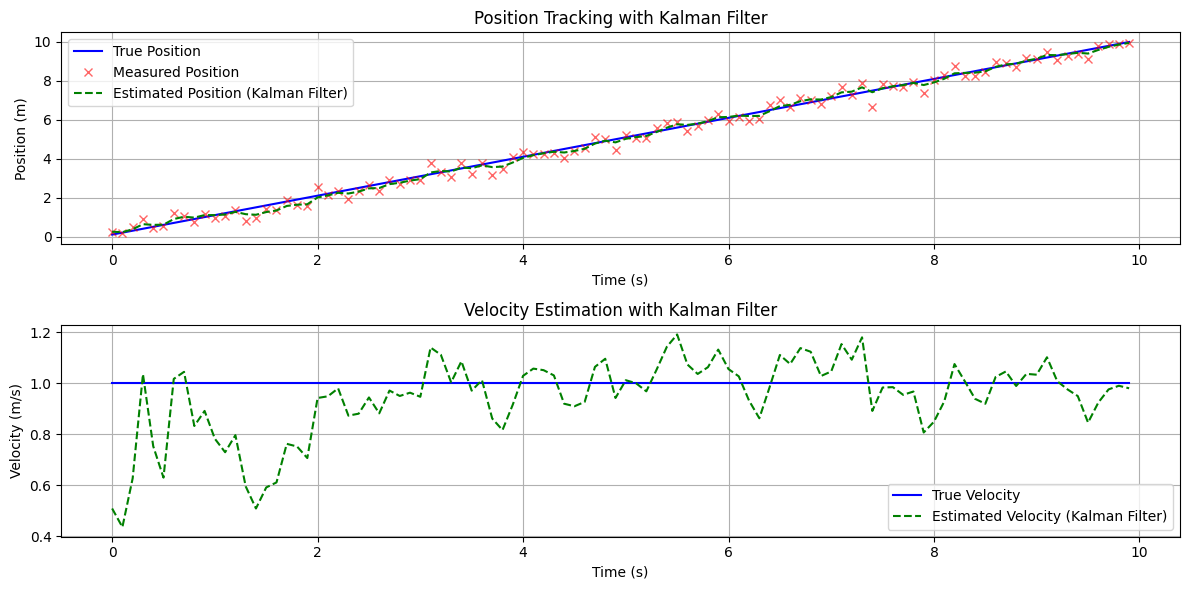

In [1]:
# 1. Implement a Kalman filter to predict and update the state of an object given its measurements.

#     A Kalman filter is an optimal estimation algorithm that uses a series of measurements observed over time, containing noise and other inaccuracies, and produces estimates of unknown variables that tend to be more precise than those based on a single measurement alone. It's widely used in various applications, from navigation systems to financial modeling.

# Here's an implementation of a Kalman filter in Python, along with an explanation of the steps involved.

# First, let's understand the core equations of the Kalman filter. It operates in two main phases: prediction and update.

# Prediction Phase (Time Update):
# This phase estimates the current state and its uncertainty based on the previous state.

# Predicted (a priori) state estimate:
# hatx∗k 
# −
#  =A
# hatx∗k−1+Bu_k−1
# where:

# hatx_k 
# −
#   is the predicted state estimate at time k.

# A is the state transition matrix, relating the previous state to the current state.

# hatx_k−1 is the estimated state at time k−1.

# B is the control input matrix.

# u_k−1 is the control input at time k−1.

# Predicted (a priori) estimate covariance:P_k 
# −
#  =AP_k−1A 
# T
#  +Q
# where:

# P_k 
# −
#   is the predicted covariance matrix at time k.

# P_k−1 is the estimated covariance matrix at time k−1.

# A 
# T
#   is the transpose of the state transition matrix.

# Q is the process noise covariance matrix, representing the uncertainty in the system's dynamics.

# Update Phase (Measurement Update):
# This phase incorporates the current measurement to refine the predicted state estimate.

# Innovation (or measurement pre-fit residual):
# tildey_k=z_k−H
# hatx_k 
# −
 
# where:

# tildey_k is the innovation.

# z_k is the actual measurement at time k.

# H is the observation matrix, relating the state to the measurement.

# Innovation (or pre-fit residual) covariance:S_k=HP_k 
# −
#  H 
# T
#  +R
# where:

# S_k is the innovation covariance.

# R is the measurement noise covariance matrix, representing the uncertainty in the measurements.

# Optimal Kalman Gain:K_k=P_k 
# −
#  H 
# T
#  S_k 
# −1
 
# where:

# K_k is the Kalman gain, which determines how much the measurements influence the state estimate.

# Updated (a posteriori) state estimate:
# hatx_k=
# hatx_k 
# −
#  +K_k
# tildey_k
# where:

# hatx_k is the updated state estimate at time k.

# Updated (a posteriori) estimate covariance:P_k=(I−K_kH)P_k 
# −
 
# where:

# P_k is the updated covariance matrix at time k.

# I is the identity matrix.

# Python Implementation of a Kalman Filter
# Let's consider a common scenario: tracking the position and velocity of an object moving in one dimension.

# System State:
# We'll define our state vector as 
# mathbfx=
# beginbmatrix
# textposition
# textvelocity
# endbmatrix.

# Assumptions:

# Constant velocity model (we'll assume the object's velocity is constant, though the filter can handle accelerations if included in the state).

# Measurements are of the object's position.



import numpy as np
import matplotlib.pyplot as plt

class KalmanFilter:
    def __init__(self, dt, initial_state, initial_covariance, process_noise_covariance, measurement_noise_covariance):
        """
        Initializes the Kalman Filter.

        Args:
            dt (float): Time step between measurements.
            initial_state (np.array): Initial state estimate (e.g., [position, velocity]).
            initial_covariance (np.array): Initial estimate covariance matrix.
            process_noise_covariance (np.array): Process noise covariance matrix (Q).
            measurement_noise_covariance (np.array): Measurement noise covariance matrix (R).
        """
        self.dt = dt
        self.x_hat = initial_state  # Initial state estimate (x_hat_k-1)
        self.P = initial_covariance  # Initial estimate covariance (P_k-1)

        self.Q = process_noise_covariance  # Process noise covariance
        self.R = measurement_noise_covariance  # Measurement noise covariance

        # State transition matrix (A) - for constant velocity model
        # x_k = x_k-1 + v_k-1 * dt
        # v_k = v_k-1
        self.A = np.array([[1, dt],
                           [0, 1]])

        # Observation matrix (H) - we measure only position
        self.H = np.array([[1, 0]])

        # Control input matrix (B) and control input (u) - assuming no external control for simplicity
        # If you had a control input (e.g., acceleration due to thrust), you'd define B and u
        self.B = np.array([[0],
                           [0]])
        self.u = np.array([[0]])

    def predict(self):
        """
        Performs the prediction (time update) step of the Kalman filter.
        Updates self.x_hat (predicted state) and self.P (predicted covariance).
        """
        # Predicted (a priori) state estimate: x_hat_k- = A * x_hat_k-1 + B * u_k-1
        self.x_hat_minus = np.dot(self.A, self.x_hat) + np.dot(self.B, self.u)

        # Predicted (a priori) estimate covariance: P_k- = A * P_k-1 * A^T + Q
        self.P_minus = np.dot(np.dot(self.A, self.P), self.A.T) + self.Q

        return self.x_hat_minus, self.P_minus

    def update(self, z_k):
        """
        Performs the update (measurement update) step of the Kalman filter.
        Updates self.x_hat (updated state) and self.P (updated covariance).

        Args:
            z_k (np.array): Current measurement (e.g., [measured_position]).
        """
        # Innovation (or measurement pre-fit residual): y_tilde_k = z_k - H * x_hat_k-
        y_tilde = z_k - np.dot(self.H, self.x_hat_minus)

        # Innovation (or pre-fit residual) covariance: S_k = H * P_k- * H^T + R
        S_k = np.dot(np.dot(self.H, self.P_minus), self.H.T) + self.R

        # Optimal Kalman Gain: K_k = P_k- * H^T * S_k^-1
        K_k = np.dot(np.dot(self.P_minus, self.H.T), np.linalg.inv(S_k))

        # Updated (a posteriori) state estimate: x_hat_k = x_hat_k- + K_k * y_tilde_k
        self.x_hat = self.x_hat_minus + np.dot(K_k, y_tilde)

        # Updated (a posteriori) estimate covariance: P_k = (I - K_k * H) * P_k-
        self.P = np.dot((np.eye(self.A.shape[0]) - np.dot(K_k, self.H)), self.P_minus)

        return self.x_hat, self.P

# --- Example Usage ---
if __name__ == "__main__":
    # Simulation parameters
    dt = 0.1  # Time step (seconds)
    num_steps = 100
    true_position = 0.0
    true_velocity = 1.0  # m/s

    # Kalman Filter parameters
    # Initial state: [initial_position, initial_velocity] - let's add some initial error
    initial_state = np.array([[0.1], [0.5]])

    # Initial covariance: High uncertainty initially
    initial_covariance = np.array([[1.0, 0.0],
                                   [0.0, 1.0]])

    # Process noise covariance (Q): Represents uncertainty in our model (e.g., small unmodeled accelerations)
    # Larger values mean we trust the model less over time.
    q_pos_var = 0.01  # Variance in position due to process noise
    q_vel_var = 0.01  # Variance in velocity due to process noise
    process_noise_covariance = np.array([[q_pos_var, 0.0],
                                         [0.0, q_vel_var]])

    # Measurement noise covariance (R): Represents uncertainty in our measurements
    # Larger values mean we trust the measurements less.
    r_pos_var = 0.1  # Variance in position measurement
    measurement_noise_covariance = np.array([[r_pos_var]])

    # Initialize Kalman filter
    kf = KalmanFilter(dt, initial_state, initial_covariance,
                      process_noise_covariance, measurement_noise_covariance)

    # Store results for plotting
    true_positions = []
    measured_positions = []
    estimated_positions = []
    estimated_velocities = []

    np.random.seed(42) # for reproducibility

    for i in range(num_steps):
        # Simulate true state evolution (constant velocity)
        true_position += true_velocity * dt
        true_positions.append(true_position)

        # Simulate noisy measurement (only position is measured)
        measurement_noise = np.random.normal(0, np.sqrt(r_pos_var))
        measured_position = true_position + measurement_noise
        measured_positions.append(measured_position)
        z_k = np.array([[measured_position]])

        # Kalman Filter steps
        kf.predict()
        kf.update(z_k)

        # Store estimated state
        estimated_positions.append(kf.x_hat[0, 0])
        estimated_velocities.append(kf.x_hat[1, 0])

    # Plotting the results
    time_steps = np.arange(0, num_steps * dt, dt)

    plt.figure(figsize=(12, 6))

    plt.subplot(2, 1, 1)
    plt.plot(time_steps, true_positions, label='True Position', color='blue')
    plt.plot(time_steps, measured_positions, 'x', label='Measured Position', color='red', alpha=0.6)
    plt.plot(time_steps, estimated_positions, label='Estimated Position (Kalman Filter)', color='green', linestyle='--')
    plt.xlabel('Time (s)')
    plt.ylabel('Position (m)')
    plt.title('Position Tracking with Kalman Filter')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.plot(time_steps, [true_velocity] * num_steps, label='True Velocity', color='blue')
    plt.plot(time_steps, estimated_velocities, label='Estimated Velocity (Kalman Filter)', color='green', linestyle='--')
    plt.xlabel('Time (s)')
    plt.ylabel('Velocity (m/s)')
    plt.title('Velocity Estimation with Kalman Filter')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [2]:
# 2. Write a function to normalize an image array such that pixel values are scaled between 0 and 1.


# The normalize_image function takes a NumPy array representing an image and scales its pixel values. It first converts the array to float64 to maintain precision during the scaling operation. It then calculates the minimum and maximum pixel values in the array.

# The core of the normalization is the min-max scaling formula:

# normalized_pixel= 
# max_value−min_value
# pixel−min_value
# ​
 
# A special case is handled where all pixel values in the image are the same (max_val == min_val). In this scenario, dividing by zero would occur. The function gracefully handles this by returning an array of zeros if the constant value is 0, or an array of ones otherwise. This ensures that the output is always within the [0, 1] range and logically consistent.

# Image normalization is a common preprocessing step in computer vision and image processing. It scales the pixel values of an image to a specific range, typically between 0 and 1. This is beneficial for several reasons:

# Consistency: It ensures that all images are treated equally, regardless of their original intensity range.

# Algorithm Performance: Many machine learning algorithms (especially neural networks) perform better when input features are normalized. It helps with faster convergence and prevents issues caused by large input values.

# Numerical Stability: Prevents numerical instability in computations, particularly when dealing with floating-point operations.

import numpy as np

def normalize_image(image_array):
    """
    Normalizes a given image array such that its pixel values are scaled between 0 and 1.

    This function handles various data types (integers, floats) and scales the
    minimum value to 0 and the maximum value to 1. If the image is constant (all
    pixels have the same value), it returns an array of zeros if the value is 0,
    otherwise an array of ones.

    Args:
        image_array (np.ndarray): The input image array. Can be of any numerical
                                  data type (e.g., uint8, int16, float32, float64).

    Returns:
        np.ndarray: The normalized image array with pixel values scaled between 0 and 1,
                    and a float64 data type.
    """
    if not isinstance(image_array, np.ndarray):
        raise TypeError("Input must be a NumPy array.")

    # Convert to float64 to ensure precision during scaling
    image_array = image_array.astype(np.float64)

    min_val = np.min(image_array)
    max_val = np.max(image_array)

    if max_val == min_val:
        # Handle cases where the image is constant (all pixels have the same value)
        if min_val == 0:
            return np.zeros_like(image_array)
        else:
            return np.ones_like(image_array)
    else:
        # Perform min-max scaling
        normalized_array = (image_array - min_val) / (max_val - min_val)
        return normalized_array

# --- Example Usage ---
if __name__ == "__main__":
    print("--- Example 1: Integer (uint8) image array ---")
    # Simulate a grayscale image with pixel values from 0 to 255
    image_uint8 = np.array([[0, 50, 100],
                            [150, 200, 255]], dtype=np.uint8)
    print("Original uint8 image array:\n", image_uint8)

    normalized_image_uint8 = normalize_image(image_uint8)
    print("Normalized uint8 image array (scaled to 0-1):\n", normalized_image_uint8)
    print("Min value:", np.min(normalized_image_uint8))
    print("Max value:", np.max(normalized_image_uint8))
    print("-" * 30)

    print("--- Example 2: Float image array with negative values ---")
    # Simulate an image with float values, including negative ones
    image_float = np.array([[-10.5, 0.0, 10.5],
                            [20.0, 5.0, -5.0]], dtype=np.float32)
    print("Original float image array:\n", image_float)

    normalized_image_float = normalize_image(image_float)
    print("Normalized float image array (scaled to 0-1):\n", normalized_image_float)
    print("Min value:", np.min(normalized_image_float))
    print("Max value:", np.max(normalized_image_float))
    print("-" * 30)

    print("--- Example 3: Image array with all same values ---")
    image_constant = np.array([[128, 128],
                               [128, 128]], dtype=np.uint8)
    print("Original constant image array:\n", image_constant)

    normalized_image_constant = normalize_image(image_constant)
    print("Normalized constant image array (scaled to 0-1):\n", normalized_image_constant)
    print("Min value:", np.min(normalized_image_constant))
    print("Max value:", np.max(normalized_image_constant))
    print("-" * 30)

    print("--- Example 4: Image array with all zeros ---")
    image_zeros = np.array([[0, 0],
                            [0, 0]], dtype=np.uint8)
    print("Original zeros image array:\n", image_zeros)

    normalized_image_zeros = normalize_image(image_zeros)
    print("Normalized zeros image array (scaled to 0-1):\n", normalized_image_zeros)
    print("Min value:", np.min(normalized_image_zeros))
    print("Max value:", np.max(normalized_image_zeros))
    print("-" * 30)

    print("--- Example 5: Single pixel image ---")
    image_single_pixel = np.array([[50]], dtype=np.uint8)
    print("Original single pixel image array:\n", image_single_pixel)

    normalized_image_single_pixel = normalize_image(image_single_pixel)
    print("Normalized single pixel image array (scaled to 0-1):\n", normalized_image_single_pixel)
    print("Min value:", np.min(normalized_image_single_pixel))
    print("Max value:", np.max(normalized_image_single_pixel))
    print("-" * 30)


--- Example 1: Integer (uint8) image array ---
Original uint8 image array:
 [[  0  50 100]
 [150 200 255]]
Normalized uint8 image array (scaled to 0-1):
 [[0.         0.19607843 0.39215686]
 [0.58823529 0.78431373 1.        ]]
Min value: 0.0
Max value: 1.0
------------------------------
--- Example 2: Float image array with negative values ---
Original float image array:
 [[-10.5   0.   10.5]
 [ 20.    5.   -5. ]]
Normalized float image array (scaled to 0-1):
 [[0.         0.3442623  0.68852459]
 [1.         0.50819672 0.18032787]]
Min value: 0.0
Max value: 1.0
------------------------------
--- Example 3: Image array with all same values ---
Original constant image array:
 [[128 128]
 [128 128]]
Normalized constant image array (scaled to 0-1):
 [[1. 1.]
 [1. 1.]]
Min value: 1.0
Max value: 1.0
------------------------------
--- Example 4: Image array with all zeros ---
Original zeros image array:
 [[0 0]
 [0 0]]
Normalized zeros image array (scaled to 0-1):
 [[0. 0.]
 [0. 0.]]
Min valu

In [3]:
# 3. Create a function to generate dummy object detection data with confidence scores and bounding boxes. Filter the detections based on a confidence threshold.


# Here are two Python functions: one to generate dummy object detection data (including bounding boxes, class labels, and confidence scores) and another to filter these detections based on a specified confidence threshold.

# This is useful for:

# Testing: Quickly creating synthetic data to test object detection post-processing logic (e.g., Non-Maximum Suppression, tracking).

# Demonstrations: Illustrating how object detection outputs are structured.

# Debugging: Generating specific scenarios (e.g., many low-confidence detections) to debug filtering logic.

# 1. generate_dummy_detections Function
# This function creates a list of dictionaries, where each dictionary represents a detected object.

# 2. filter_detections_by_confidence Function
# This function takes the generated detections and a threshold, returning only those detections that meet or exceed the confidence score.


import numpy as np
import random

def generate_dummy_detections(num_detections, image_width, image_height, class_labels):
    """
    Generates dummy object detection data with bounding boxes, class labels, and confidence scores.

    Args:
        num_detections (int): The number of dummy detections to generate.
        image_width (int): The width of the image for which detections are generated.
        image_height (int): The height of the image for which detections are generated.
        class_labels (list): A list of possible class labels (strings) for the objects.

    Returns:
        list: A list of dictionaries, where each dictionary represents a detection
              with 'box' (list of [x_min, y_min, x_max, y_max]), 'label' (str),
              and 'score' (float).
    """
    detections = []
    for _ in range(num_detections):
        # Generate random top-left corner (x_min, y_min)
        x_min = random.uniform(0, image_width * 0.8)
        y_min = random.uniform(0, image_height * 0.8)

        # Generate random width and height for the box, ensuring x_max, y_max are within image bounds
        box_width = random.uniform(20, image_width * 0.2)
        box_height = random.uniform(20, image_height * 0.2)

        x_max = min(x_min + box_width, image_width)
        y_max = min(y_min + box_height, image_height)

        # Ensure x_min, y_min are less than x_max, y_max (in case of min() adjustments)
        if x_max - x_min < 5: x_max = x_min + 5 # Minimum width of 5 pixels
        if y_max - y_min < 5: y_max = y_min + 5 # Minimum height of 5 pixels

        # Generate a random confidence score between 0.1 and 0.99
        score = random.uniform(0.1, 0.99)

        # Randomly select a class label
        label = random.choice(class_labels)

        detection = {
            'box': [int(x_min), int(y_min), int(x_max), int(y_max)],
            'label': label,
            'score': round(score, 3) # Round score for cleaner output
        }
        detections.append(detection)
    return detections

def filter_detections_by_confidence(detections, confidence_threshold):
    """
    Filters a list of object detections based on a confidence threshold.

    Args:
        detections (list): A list of detection dictionaries, as generated by
                           `generate_dummy_detections`.
        confidence_threshold (float): The minimum confidence score required for a
                                      detection to be included in the filtered list.

    Returns:
        list: A new list containing only the detections that meet or exceed the
              specified confidence threshold.
    """
    if not (0.0 <= confidence_threshold <= 1.0):
        raise ValueError("Confidence threshold must be between 0.0 and 1.0.")

    filtered_detections = [
        d for d in detections if d['score'] >= confidence_threshold
    ]
    return filtered_detections

# --- Example Usage ---
if __name__ == "__main__":
    # Define parameters for dummy data generation
    num_dummy_detections = 15
    image_width = 640
    image_height = 480
    possible_labels = ['car', 'person', 'bicycle', 'dog', 'traffic_light']

    print(f"Generating {num_dummy_detections} dummy detections for an image of {image_width}x{image_height}...\n")

    # Generate dummy detections
    dummy_detections = generate_dummy_detections(
        num_dummy_detections, image_width, image_height, possible_labels
    )

    print("--- Original Dummy Detections ---")
    for i, det in enumerate(dummy_detections):
        print(f"Detection {i+1}: Box={det['box']}, Label='{det['label']}', Score={det['score']}")
    print("\n" + "="*50 + "\n")

    # Filter detections based on a confidence threshold
    confidence_threshold = 0.65
    print(f"Filtering detections with a confidence threshold of {confidence_threshold}...\n")

    filtered_results = filter_detections_by_confidence(dummy_detections, confidence_threshold)

    print(f"--- Filtered Detections (Score >= {confidence_threshold}) ---")
    if filtered_results:
        for i, det in enumerate(filtered_results):
            print(f"Filtered Detection {i+1}: Box={det['box']}, Label='{det['label']}', Score={det['score']}")
    else:
        print("No detections met the confidence threshold.")
    print("\n" + "="*50 + "\n")

    # Example with a very low threshold (should show most detections)
    low_threshold = 0.1
    print(f"Filtering detections with a very low confidence threshold of {low_threshold}...\n")
    filtered_low_thresh = filter_detections_by_confidence(dummy_detections, low_threshold)
    print(f"Number of detections with score >= {low_threshold}: {len(filtered_low_thresh)}")

    # Example with a very high threshold (should show few or no detections)
    high_threshold = 0.95
    print(f"\nFiltering detections with a very high confidence threshold of {high_threshold}...\n")
    filtered_high_thresh = filter_detections_by_confidence(dummy_detections, high_threshold)
    print(f"Number of detections with score >= {high_threshold}: {len(filtered_high_thresh)}")


Generating 15 dummy detections for an image of 640x480...

--- Original Dummy Detections ---
Detection 1: Box=[362, 302, 414, 366], Label='person', Score=0.852
Detection 2: Box=[487, 69, 552, 146], Label='car', Score=0.795
Detection 3: Box=[304, 143, 331, 189], Label='person', Score=0.35
Detection 4: Box=[151, 374, 189, 405], Label='car', Score=0.6
Detection 5: Box=[483, 318, 604, 405], Label='bicycle', Score=0.429
Detection 6: Box=[320, 382, 369, 432], Label='bicycle', Score=0.511
Detection 7: Box=[441, 248, 477, 274], Label='bicycle', Score=0.51
Detection 8: Box=[417, 103, 543, 165], Label='car', Score=0.633
Detection 9: Box=[129, 9, 166, 31], Label='bicycle', Score=0.639
Detection 10: Box=[455, 275, 524, 329], Label='person', Score=0.635
Detection 11: Box=[270, 163, 296, 219], Label='person', Score=0.909
Detection 12: Box=[482, 86, 540, 148], Label='dog', Score=0.939
Detection 13: Box=[404, 146, 499, 196], Label='traffic_light', Score=0.461
Detection 14: Box=[459, 293, 490, 338], La

In [4]:
# 4. Write a function that takes a list of YOLO detections and extracts a random 128-dimensional feature vector for each detection.

                                                                                                             
#                                                                                                              When working with object detection models like YOLO, it's common to extract feature vectors for each detected object. These features can then be used for various downstream tasks such as object re-identification, tracking, or clustering.

# Since actual feature extraction from a deep learning model would require the model itself and image data, this function will simulate the process by generating random 128-dimensional feature vectors for each detection. This is useful for:

# Prototyping: Testing pipelines that consume feature vectors without needing a full-fledged deep learning model.

# Data Structure Understanding: Demonstrating how feature vectors might be associated with detection results.

# Developing Downstream Algorithms: Building and testing algorithms (e.g., similarity search, clustering) that operate on these feature vectors.

# extract_random_features_from_detections Function
# This function will take a list of YOLO-like detection dictionaries and add a new feature_vector key to each, containing a randomly generated 128-dimensional NumPy array.


import numpy as np
import random

def extract_random_features_from_detections(yolo_detections, feature_dimension=128):
    """
    Takes a list of YOLO detections and extracts (generates random)
    a feature vector for each detection.

    In a real-world scenario, this would involve passing the cropped
    region of interest (ROI) from the image through a feature extractor
    (e.g., a pre-trained CNN layer). For this dummy function, we
    generate random feature vectors.

    Args:
        yolo_detections (list): A list of dictionaries, where each dictionary
                                represents a YOLO detection. Expected keys include
                                'box', 'label', and 'score'.
        feature_dimension (int): The desired dimension of the feature vector.
                                 Defaults to 128.

    Returns:
        list: The updated list of dictionaries, where each detection now
              includes a 'feature_vector' key with a NumPy array.
    """
    if not isinstance(yolo_detections, list):
        raise TypeError("Input 'yolo_detections' must be a list.")
    if not all(isinstance(d, dict) for d in yolo_detections):
        raise ValueError("Each item in 'yolo_detections' must be a dictionary.")
    if not isinstance(feature_dimension, int) or feature_dimension <= 0:
        raise ValueError("feature_dimension must be a positive integer.")

    detections_with_features = []
    for detection in yolo_detections:
        # Create a copy of the detection dictionary to avoid modifying the original list directly
        # if the user intends to keep the original list unchanged elsewhere.
        detection_copy = detection.copy()

        # Generate a random 128-dimensional feature vector
        # Using np.random.rand() for values between 0 and 1, then scaling for more variety
        feature_vector = np.random.rand(feature_dimension) * 10 - 5 # Values between -5 and 5
        detection_copy['feature_vector'] = feature_vector.astype(np.float32) # Store as float32 for typical ML use

        detections_with_features.append(detection_copy)

    return detections_with_features

# --- Helper function to generate dummy detections (reused from previous task) ---
def generate_dummy_detections(num_detections, image_width, image_height, class_labels):
    """
    Generates dummy object detection data with bounding boxes, class labels, and confidence scores.
    """
    detections = []
    for _ in range(num_detections):
        x_min = random.uniform(0, image_width * 0.8)
        y_min = random.uniform(0, image_height * 0.8)
        box_width = random.uniform(20, image_width * 0.2)
        box_height = random.uniform(20, image_height * 0.2)
        x_max = min(x_min + box_width, image_width)
        y_max = min(y_min + box_height, image_height)

        if x_max - x_min < 5: x_max = x_min + 5
        if y_max - y_min < 5: y_max = y_min + 5

        score = random.uniform(0.1, 0.99)
        label = random.choice(class_labels)

        detection = {
            'box': [int(x_min), int(y_min), int(x_max), int(y_max)],
            'label': label,
            'score': round(score, 3)
        }
        detections.append(detection)
    return detections

# --- Example Usage ---
if __name__ == "__main__":
    # 1. Generate some dummy YOLO detections first
    num_dummy_detections = 5
    image_width = 640
    image_height = 480
    possible_labels = ['person', 'car', 'dog']

    print("--- Generating Dummy Detections ---")
    dummy_yolo_detections = generate_dummy_detections(
        num_dummy_detections, image_width, image_height, possible_labels
    )
    for i, det in enumerate(dummy_yolo_detections):
        print(f"Original Detection {i+1}: Label='{det['label']}', Score={det['score']}, Box={det['box']}")
    print("\n" + "="*50 + "\n")

    # 2. Extract random 128-dimensional feature vectors for each detection
    print("--- Extracting Random Feature Vectors (128-dim) ---")
    detections_with_features = extract_random_features_from_detections(dummy_yolo_detections, feature_dimension=128)

    for i, det in enumerate(detections_with_features):
        print(f"Detection {i+1}:")
        print(f"  Label: {det['label']}")
        print(f"  Score: {det['score']}")
        print(f"  Box: {det['box']}")
        # Print only the first few and last few elements of the feature vector for brevity
        print(f"  Feature Vector (first 5): {det['feature_vector'][:5]}...")
        print(f"  Feature Vector (last 5): ...{det['feature_vector'][-5:]}")
        print(f"  Feature Vector Shape: {det['feature_vector'].shape}")
        print("-" * 20)

    print("\n" + "="*50 + "\n")

    # Example with a different feature dimension
    print("--- Extracting Random Feature Vectors (64-dim) ---")
    detections_with_64_dim_features = extract_random_features_from_detections(dummy_yolo_detections, feature_dimension=64)
    for i, det in enumerate(detections_with_64_dim_features):
        print(f"Detection {i+1}: Feature Vector Shape: {det['feature_vector'].shape}")

--- Generating Dummy Detections ---
Original Detection 1: Label='car', Score=0.747, Box=[497, 131, 570, 161]
Original Detection 2: Label='car', Score=0.305, Box=[224, 39, 328, 131]
Original Detection 3: Label='person', Score=0.272, Box=[147, 217, 178, 277]
Original Detection 4: Label='person', Score=0.558, Box=[411, 184, 444, 236]
Original Detection 5: Label='person', Score=0.549, Box=[365, 88, 444, 115]


--- Extracting Random Feature Vectors (128-dim) ---
Detection 1:
  Label: car
  Score: 0.747
  Box: [497, 131, 570, 161]
  Feature Vector (first 5): [-0.82588995 -2.7789218  -3.8013463  -1.6238483   4.429097  ]...
  Feature Vector (last 5): ...[-1.8307799 -3.3050725  0.5680126  4.361548   1.960298 ]
  Feature Vector Shape: (128,)
--------------------
Detection 2:
  Label: car
  Score: 0.305
  Box: [224, 39, 328, 131]
  Feature Vector (first 5): [ 0.7006117 -4.028235   1.1500722  4.9005384 -3.59916  ]...
  Feature Vector (last 5): ...[1.9673717 1.2894285 3.7747202 2.3507104 3.0348094]

In [1]:
# 5. Write a function to re-identify objects by matching feature vectors based on Euclidean distance.


import numpy as np

def reidentify_objects_euclidean(existing_features, new_features):
    """
    Re-identifies objects by matching new feature vectors to existing feature vectors
    based on Euclidean distance.

    Args:
        existing_features (list or np.ndarray): A list or NumPy array of feature vectors
                                                representing existing objects. Each row
                                                is a feature vector.
        new_features (list or np.ndarray): A list or NumPy array of feature vectors
                                           representing new objects to be identified.
                                           Each row is a feature vector.

    Returns:
        list: A list of tuples, where each tuple (new_idx, existing_idx, distance)
              indicates that the new_feature at 'new_idx' best matches the
              existing_feature at 'existing_idx' with the given Euclidean distance.
              Returns an empty list if either input is empty.
    """
    if not existing_features or not new_features:
        print("Warning: One or both input feature lists are empty. Returning empty list.")
        return []

    # Convert lists to NumPy arrays for efficient computation
    existing_features = np.array(existing_features)
    new_features = np.array(new_features)

    # Ensure feature vectors have the same dimension
    if existing_features.shape[1] != new_features.shape[1]:
        raise ValueError("Feature vector dimensions must be consistent.")

    matches = []

    # Iterate through each new feature vector
    for i, new_feat in enumerate(new_features):
        min_distance = float('inf')
        best_match_idx = -1

        # Compare with each existing feature vector
        for j, existing_feat in enumerate(existing_features):
            # Calculate Euclidean distance
            # distance = np.linalg.norm(new_feat - existing_feat)
            # A more explicit way to calculate Euclidean distance:
            distance = np.sqrt(np.sum((new_feat - existing_feat)**2))

            if distance < min_distance:
                min_distance = distance
                best_match_idx = j

        matches.append((i, best_match_idx, min_distance))

    return matches

# --- Example Usage ---
if __name__ == "__main__":
    # Example 1: Simple 2D feature vectors
    print("--- Example 1: Simple 2D feature vectors ---")
    existing_objects_features_2d = [
        [1.0, 2.0],  # Object A
        [5.0, 6.0],  # Object B
        [9.0, 0.0]   # Object C
    ]

    new_objects_features_2d = [
        [1.1, 2.2],  # Should match Object A
        [5.3, 5.8],  # Should match Object B
        [9.1, 0.3],  # Should match Object C
        [1.5, 2.5]   # Also should match Object A, but might be further
    ]

    matches_2d = reidentify_objects_euclidean(existing_objects_features_2d, new_objects_features_2d)
    print("Matches (New Index, Existing Index, Distance):")
    for new_idx, existing_idx, dist in matches_2d:
        print(f"  New object {new_idx} (features: {new_objects_features_2d[new_idx]}) "
              f"matches existing object {existing_idx} (features: {existing_objects_features_2d[existing_idx]}) "
              f"with distance: {dist:.4f}")
    print("\n")

    # Example 2: Higher-dimensional feature vectors
    print("--- Example 2: Higher-dimensional feature vectors ---")
    existing_objects_features_hd = [
        [0.1, 0.2, 0.3, 0.4, 0.5],
        [1.0, 1.1, 1.2, 1.3, 1.4],
        [2.0, 2.0, 2.0, 2.0, 2.0]
    ]

    new_objects_features_hd = [
        [0.11, 0.22, 0.33, 0.44, 0.55], # Close to first existing
        [1.05, 1.15, 1.25, 1.35, 1.45], # Close to second existing
        [0.9, 0.9, 0.9, 0.9, 0.9]       # Closest to second existing
    ]

    matches_hd = reidentify_objects_euclidean(existing_objects_features_hd, new_objects_features_hd)
    print("Matches (New Index, Existing Index, Distance):")
    for new_idx, existing_idx, dist in matches_hd:
        print(f"  New object {new_idx} (features: {new_objects_features_hd[new_idx]}) "
              f"matches existing object {existing_idx} (features: {existing_objects_features_hd[existing_idx]}) "
              f"with distance: {dist:.4f}")
    print("\n")

    # Example 3: Empty input
    print("--- Example 3: Empty input ---")
    empty_matches = reidentify_objects_euclidean([], new_objects_features_2d)
    print(f"Result for empty existing features: {empty_matches}")
    empty_matches_2 = reidentify_objects_euclidean(existing_objects_features_2d, [])
    print(f"Result for empty new features: {empty_matches_2}")



--- Example 1: Simple 2D feature vectors ---
Matches (New Index, Existing Index, Distance):
  New object 0 (features: [1.1, 2.2]) matches existing object 0 (features: [1.0, 2.0]) with distance: 0.2236
  New object 1 (features: [5.3, 5.8]) matches existing object 1 (features: [5.0, 6.0]) with distance: 0.3606
  New object 2 (features: [9.1, 0.3]) matches existing object 2 (features: [9.0, 0.0]) with distance: 0.3162
  New object 3 (features: [1.5, 2.5]) matches existing object 0 (features: [1.0, 2.0]) with distance: 0.7071


--- Example 2: Higher-dimensional feature vectors ---
Matches (New Index, Existing Index, Distance):
  New object 0 (features: [0.11, 0.22, 0.33, 0.44, 0.55]) matches existing object 0 (features: [0.1, 0.2, 0.3, 0.4, 0.5]) with distance: 0.0742
  New object 1 (features: [1.05, 1.15, 1.25, 1.35, 1.45]) matches existing object 1 (features: [1.0, 1.1, 1.2, 1.3, 1.4]) with distance: 0.1118
  New object 2 (features: [0.9, 0.9, 0.9, 0.9, 0.9]) matches existing object 1 (f

In [12]:
# 6. Write a function to track object positions using YOLO detections and a Kalman Filter.

import numpy as np
from scipy.optimize import linear_sum_assignment
from scipy.stats import chi2

# --- Kalman Filter Class ---
class KalmanFilter:
    """
    A simple Kalman Filter implementation for 2D object tracking.
    State vector: [x, y, vx, vy] (position x, position y, velocity x, velocity y)
    Measurement vector: [x, y] (observed position x, observed position y)
    """
    def __init__(self, initial_state, initial_covariance, process_noise_cov, measurement_noise_cov):
        """
        Initializes the Kalman Filter.

        Args:
            initial_state (np.array): Initial state vector [x, y, vx, vy].
            initial_covariance (np.array): Initial state covariance matrix.
            process_noise_cov (np.array): Process noise covariance matrix (Q).
            measurement_noise_cov (np.array): Measurement noise covariance matrix (R).
        """
        self.x = initial_state  # State vector
        self.P = initial_covariance  # State covariance matrix

        # State transition matrix (A) - assumes constant velocity model
        # x_k = x_{k-1} + vx * dt
        # y_k = y_{k-1} + vy * dt
        # vx_k = vx_{k-1}
        # vy_k = vy_{k-1}
        self.A = np.array([
            [1, 0, 1, 0],  # x = x + vx*dt (dt=1 for simplicity, assuming constant time step)
            [0, 1, 0, 1],  # y = y + vy*dt
            [0, 0, 1, 0],  # vx = vx
            [0, 0, 0, 1]   # vy = vy
        ], dtype=float)

        # Measurement matrix (H) - maps state to measurement
        # We measure [x, y] from the state [x, y, vx, vy]
        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ], dtype=float)

        self.Q = process_noise_cov  # Process noise covariance
        self.R = measurement_noise_cov  # Measurement noise covariance

        # Identity matrix for convenience
        self.I = np.eye(self.x.shape[0])

    def predict(self):
        """
        Predicts the next state and covariance.
        x_k = A * x_{k-1}
        P_k = A * P_{k-1} * A_T + Q
        """
        self.x = self.A @ self.x
        self.P = self.A @ self.P @ self.A.T + self.Q
        return self.x, self.P

    def update(self, z):
        """
        Updates the state and covariance based on a new measurement.
        y = z - H * x_k (measurement residual)
        S = H * P_k * H_T + R (residual covariance)
        K = P_k * H_T * S_inv (Kalman gain)
        x_k_new = x_k + K * y
        P_k_new = (I - K * H) * P_k
        """
        # Measurement residual
        y = z - (self.H @ self.x)

        # Residual covariance
        S = self.H @ self.P @ self.H.T + self.R

        # Kalman gain
        K = self.P @ self.H.T @ np.linalg.inv(S)

        # Updated state estimate
        self.x = self.x + (K @ y)

        # Updated state covariance
        self.P = (self.I - K @ self.H) @ self.P
        return self.x, self.P

# --- Track Class ---
class Track:
    """
    Represents a single object track managed by a Kalman Filter.
    """
    _next_id = 0  # Class-level counter for unique track IDs

    def __init__(self, detection, kalman_filter_params):
        """
        Initializes a new track from a detection.

        Args:
            detection (np.array): Initial detection [x, y, w, h, class_id].
            kalman_filter_params (dict): Dictionary containing KF parameters.
        """
        self.track_id = Track._next_id
        Track._next_id += 1

        # Initial state for KF: [x, y, vx, vy]
        # Assuming initial velocities are zero
        initial_state = np.array([detection[0], detection[1], 0.0, 0.0])
        initial_covariance = kalman_filter_params['initial_covariance']
        process_noise_cov = kalman_filter_params['process_noise_cov']
        measurement_noise_cov = kalman_filter_params['measurement_noise_cov']

        self.kf = KalmanFilter(initial_state, initial_covariance, process_noise_cov, measurement_noise_cov)
        self.class_id = int(detection[4])

        self.history = [self.kf.x[:2]]  # Store only position (x, y)
        self.hits = 1  # Number of consecutive detections
        self.misses = 0  # Number of consecutive missed detections
        self.age = 0  # Total frames the track has existed

        # Bounding box associated with the last update
        self.bbox = detection[0:4]

    def predict(self):
        """Predicts the next state using the Kalman Filter."""
        predicted_state, predicted_covariance = self.kf.predict()
        return predicted_state, predicted_covariance

    def update(self, detection):
        """
        Updates the track with a new detection.

        Args:
            detection (np.array): The new detection [x, y, w, h, class_id].
        """
        # Update Kalman Filter with the measured position [x, y]
        self.kf.update(detection[0:2])
        self.history.append(self.kf.x[:2])
        self.hits += 1
        self.misses = 0  # Reset misses on a hit
        self.bbox = detection[0:4] # Update bounding box with the latest detection's bbox

    def increment_age(self):
        """Increments the age of the track."""
        self.age += 1

    def increment_misses(self):
        """Increments the miss count for the track."""
        self.misses += 1
        self.hits = 0 # Reset hits on a miss

# --- Object Tracker Class ---
class ObjectTracker:
    """
    Manages multiple object tracks using Kalman Filters and performs data association.
    """
    def __init__(self,
                 max_misses=10,
                 min_hits_to_confirm=3,
                 iou_threshold=0.3,
                 mahalanobis_threshold_factor=4.0, # Multiplier for Mahalanobis distance threshold
                 kalman_filter_params=None):
        """
        Initializes the object tracker.

        Args:
            max_misses (int): Maximum number of consecutive frames a track can be missed before deletion.
            min_hits_to_confirm (int): Minimum number of hits for a track to be considered 'confirmed'.
            iou_threshold (float): IoU threshold for initial coarse association (not used in this KF-based example,
                                   but good to keep for general tracking context or hybrid approaches).
            mahalanobis_threshold_factor (float): Factor to scale the Mahalanobis distance threshold.
                                                  Higher values allow more distant associations.
            kalman_filter_params (dict): Dictionary of parameters for initializing Kalman Filters.
        """
        self.tracks = []
        self.max_misses = max_misses
        self.min_hits_to_confirm = min_hits_to_confirm
        self.iou_threshold = iou_threshold # Not directly used for KF association, but useful for other methods
        self.mahalanobis_threshold_factor = mahalanobis_threshold_factor

        # Default Kalman Filter parameters if not provided
        if kalman_filter_params is None:
            # Initial covariance (P): High uncertainty initially
            P_init = np.diag([100, 100, 10, 10]) # x, y, vx, vy

            # Process noise covariance (Q): How much noise is in the system model
            # Higher values mean more trust in measurements over predictions
            Q_process = np.diag([1, 1, 0.1, 0.1]) # Smaller for velocities if they are expected to be constant

            # Measurement noise covariance (R): How much noise is in the measurements
            # Higher values mean less trust in measurements
            R_measurement = np.diag([10, 10]) # For x, y measurements

            self.kalman_filter_params = {
                'initial_covariance': P_init,
                'process_noise_cov': Q_process,
                'measurement_noise_cov': R_measurement
            }
        else:
            self.kalman_filter_params = kalman_filter_params

    def _calculate_mahalanobis_distance(self, mean, cov, measurement):
        """
        Calculates the Mahalanobis distance between a predicted state and a measurement.

        Args:
            mean (np.array): Predicted mean of the state (or measurement space).
            cov (np.array): Covariance matrix of the predicted state (or measurement space).
            measurement (np.array): The actual measurement.

        Returns:
            float: The Mahalanobis distance.
        """
        diff = measurement - mean
        inv_cov = np.linalg.inv(cov)
        return np.sqrt(diff.T @ inv_cov @ diff)

    def update(self, detections):
        """
        Updates the tracker with new detections.

        Args:
            detections (list of np.array): List of current frame detections.
                                           Each detection is [x, y, w, h, class_id].
                                           x, y are center coordinates.
        Returns:
            list of Track: The list of active tracks after update.
        """
        if len(self.tracks) == 0 and len(detections) == 0:
            return []

        # 1. Predict all existing tracks
        predicted_states = []
        predicted_covariances = []
        for track in self.tracks:
            predicted_state, predicted_covariance = track.predict()
            predicted_states.append(predicted_state)
            predicted_covariances.append(predicted_covariance)

        num_tracks = len(self.tracks)
        num_detections = len(detections)

        # Initialize cost matrix (Mahalanobis distance)
        cost_matrix = np.full((num_tracks, num_detections), np.inf)

        # Calculate Mahalanobis distance for each track-detection pair
        # Mahalanobis distance is calculated in the measurement space.
        # S = H * P_k * H_T + R
        # This S is the residual covariance used in the update step of KF.
        # We use it here to calculate the Mahalanobis distance.
        for i, track in enumerate(self.tracks):
            for j, detection in enumerate(detections):
                # Predicted measurement and its covariance
                predicted_measurement = track.kf.H @ predicted_states[i]
                predicted_measurement_cov = track.kf.H @ predicted_covariances[i] @ track.kf.H.T + track.kf.R

                # Calculate Mahalanobis distance
                try:
                    distance = self._calculate_mahalanobis_distance(
                        predicted_measurement,
                        predicted_measurement_cov,
                        detection[0:2] # Use only x, y for measurement
                    )
                    cost_matrix[i, j] = distance
                except np.linalg.LinAlgError:
                    # Handle singular matrix error if it occurs
                    cost_matrix[i, j] = np.inf
                    print(f"Warning: Singular matrix encountered for track {track.track_id} and detection {j}.")

        # Apply Mahalanobis distance threshold
        # Chi-squared distribution for 2 degrees of freedom (x, y)
        # For 95% confidence, chi2.ppf(0.95, 2) is approx 5.99
        # We multiply by a factor to make it more permissive or restrictive
        mahalanobis_threshold = chi2.ppf(0.95, 2) * self.mahalanobis_threshold_factor

        # Set costs above threshold to infinity to prevent assignment
        cost_matrix[cost_matrix > mahalanobis_threshold] = np.inf

        # 2. Assign detections to tracks using Hungarian algorithm
        row_ind, col_ind = linear_sum_assignment(cost_matrix)

        # Keep only valid assignments (where cost is not infinity)
        assignments = []
        for r, c in zip(row_ind, col_ind):
            if cost_matrix[r, c] != np.inf:
                assignments.append((r, c))

        assigned_track_indices = set([r for r, _ in assignments])
        assigned_detection_indices = set([c for _, c in assignments])

        # 3. Update assigned tracks
        for track_idx, detection_idx in assignments:
            self.tracks[track_idx].update(detections[detection_idx])

        # 4. Handle unassigned detections (create new tracks)
        for i, detection in enumerate(detections):
            if i not in assigned_detection_indices:
                new_track = Track(detection, self.kalman_filter_params)
                self.tracks.append(new_track)

        # 5. Handle unassigned tracks (increment misses)
        tracks_to_remove = []
        for i, track in enumerate(self.tracks):
            if i not in assigned_track_indices:
                track.increment_misses()
            track.increment_age()

            # Remove tracks that have been missed too many times
            if track.misses > self.max_misses:
                tracks_to_remove.append(i)

        # Remove tracks in reverse order to avoid index issues
        for idx in sorted(tracks_to_remove, reverse=True):
            del self.tracks[idx]

        return self.get_tracks()

    def get_tracks(self):
        """
        Returns a list of confirmed tracks.
        """
        # Optionally, filter for confirmed tracks based on min_hits_to_confirm
        # For simplicity, returning all active tracks here.
        # return [track for track in self.tracks if track.hits >= self.min_hits_to_confirm]
        return self.tracks

# --- Example Usage ---
def run_tracking_simulation():
    """
    Simulates object tracking over several frames.
    """
    print("Starting object tracking simulation...")

    # Initialize the tracker
    tracker = ObjectTracker(max_misses=5, min_hits_to_confirm=2)

    # Simulate detections over frames
    # Each detection: [center_x, center_y, width, height, class_id]

    # Frame 1: Two objects appear
    frame1_detections = [
        np.array([100, 100, 20, 20, 0]),  # Object 0 (class 0)
        np.array([200, 200, 25, 25, 1])   # Object 1 (class 1)
    ]
    print("\n--- Frame 1 ---")
    active_tracks = tracker.update(frame1_detections)
    print(f"Detections: {frame1_detections}")
    for track in active_tracks:
        print(f"Track ID: {track.track_id}, Class: {track.class_id}, Position: {track.kf.x[:2].round(2)}, Hits: {track.hits}, Misses: {track.misses}")

    # Frame 2: Objects move slightly, one new object appears
    frame2_detections = [
        np.array([102, 103, 20, 20, 0]),  # Object 0 moved
        np.array([203, 201, 25, 25, 1]),  # Object 1 moved
        np.array([50, 50, 18, 18, 0])     # New Object 2 (class 0)
    ]
    print("\n--- Frame 2 ---")
    active_tracks = tracker.update(frame2_detections)
    print(f"Detections: {frame2_detections}")
    for track in active_tracks:
        print(f"Track ID: {track.track_id}, Class: {track.class_id}, Position: {track.kf.x[:2].round(2)}, Hits: {track.hits}, Misses: {track.misses}")

    # Frame 3: Objects continue to move, one object is temporarily missed (Object 1)
    frame3_detections = [
        np.array([105, 106, 20, 20, 0]),  # Object 0 moved
        np.array([52, 51, 18, 18, 0])     # Object 2 moved
        # Object 1 (original ID 1) is missed
    ]
    print("\n--- Frame 3 ---")
    active_tracks = tracker.update(frame3_detections)
    print(f"Detections: {frame3_detections}")
    for track in active_tracks:
        print(f"Track ID: {track.track_id}, Class: {track.class_id}, Position: {track.kf.x[:2].round(2)}, Hits: {track.hits}, Misses: {track.misses}")

    # Frame 4: Object 1 reappears
    frame4_detections = [
        np.array([107, 108, 20, 20, 0]),  # Object 0 moved
        np.array([206, 204, 25, 25, 1]),  # Object 1 reappears
        np.array([54, 53, 18, 18, 0])     # Object 2 moved
    ]
    print("\n--- Frame 4 ---")
    active_tracks = tracker.update(frame4_detections)
    print(f"Detections: {frame4_detections}")
    for track in active_tracks:
        print(f"Track ID: {track.track_id}, Class: {track.class_id}, Position: {track.kf.x[:2].round(2)}, Hits: {track.hits}, Misses: {track.misses}")

    # Frame 5: One object leaves the scene (Object 2)
    frame5_detections = [
        np.array([110, 111, 20, 20, 0]),  # Object 0 moved
        np.array([209, 207, 25, 25, 1])   # Object 1 moved
        # Object 2 (original ID 2) is missed
    ]
    print("\n--- Frame 5 ---")
    active_tracks = tracker.update(frame5_detections)
    print(f"Detections: {frame5_detections}")
    for track in active_tracks:
        print(f"Track ID: {track.track_id}, Class: {track.class_id}, Position: {track.kf.x[:2].round(2)}, Hits: {track.hits}, Misses: {track.misses}")

    # Frame 6: Object 2 is still missed, should be removed soon
    frame6_detections = [
        np.array([112, 113, 20, 20, 0]),  # Object 0 moved
        np.array([212, 210, 25, 25, 1])   # Object 1 moved
    ]
    print("\n--- Frame 6 ---")
    active_tracks = tracker.update(frame6_detections)
    print(f"Detections: {frame6_detections}")
    for track in active_tracks:
        print(f"Track ID: {track.track_id}, Class: {track.class_id}, Position: {track.kf.x[:2].round(2)}, Hits: {track.hits}, Misses: {track.misses}")

    # Frame 7: Object 2 is gone
    frame7_detections = [
        np.array([114, 115, 20, 20, 0]),  # Object 0 moved
        np.array([215, 213, 25, 25, 1])   # Object 1 moved
    ]
    print("\n--- Frame 7 ---")
    active_tracks = tracker.update(frame7_detections)
    print(f"Detections: {frame7_detections}")
    for track in active_tracks:
        print(f"Track ID: {track.track_id}, Class: {track.class_id}, Position: {track.kf.x[:2].round(2)}, Hits: {track.hits}, Misses: {track.misses}")

    print("\nSimulation complete.")

# To run the simulation, uncomment the following line:
run_tracking_simulation()



Starting object tracking simulation...

--- Frame 1 ---
Detections: [array([100, 100,  20,  20,   0]), array([200, 200,  25,  25,   1])]
Track ID: 0, Class: 0, Position: [100. 100.], Hits: 0, Misses: 1
Track ID: 1, Class: 1, Position: [200. 200.], Hits: 0, Misses: 1

--- Frame 2 ---
Detections: [array([102, 103,  20,  20,   0]), array([203, 201,  25,  25,   1]), array([50, 50, 18, 18,  0])]
Track ID: 0, Class: 0, Position: [101.83 102.75], Hits: 1, Misses: 0
Track ID: 1, Class: 1, Position: [202.75 200.92], Hits: 1, Misses: 0
Track ID: 2, Class: 0, Position: [50. 50.], Hits: 0, Misses: 1

--- Frame 3 ---
Detections: [array([105, 106,  20,  20,   0]), array([52, 51, 18, 18,  0])]
Track ID: 0, Class: 0, Position: [104.04 105.04], Hits: 2, Misses: 0
Track ID: 1, Class: 1, Position: [203. 201.], Hits: 0, Misses: 1
Track ID: 2, Class: 0, Position: [51.83 50.92], Hits: 1, Misses: 0

--- Frame 4 ---
Detections: [array([107, 108,  20,  20,   0]), array([206, 204,  25,  25,   1]), array([54, 53

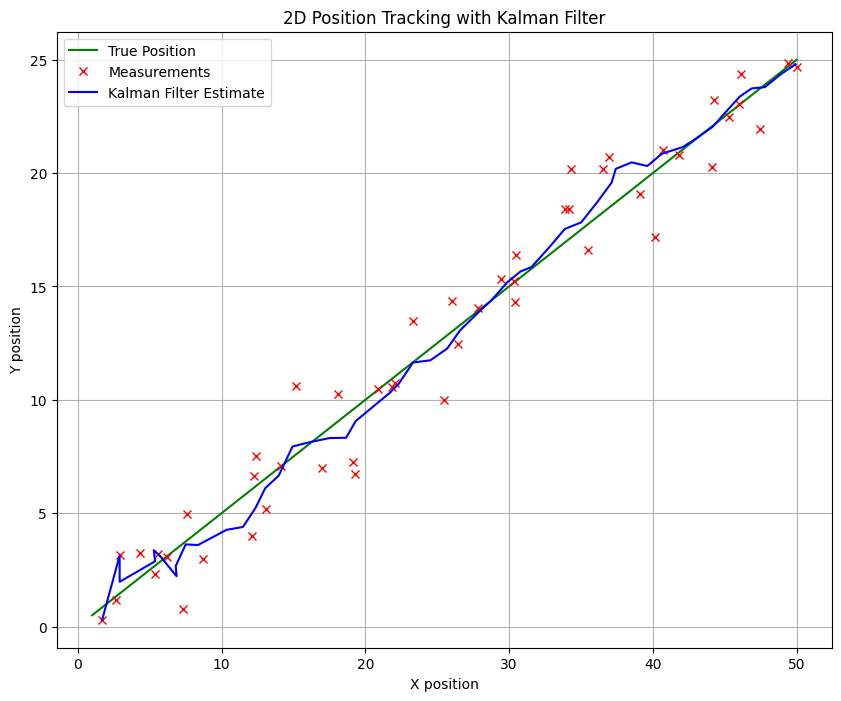

In [4]:
# 7. Implement a simple Kalman Filter to track an object's position in a 2D space (simulate the object's movement with random noise).

import numpy as np
import matplotlib.pyplot as plt

# --- 1. Simulate object movement ---
np.random.seed(42)

# Number of time steps
n_steps = 50

# True initial position and velocity
x = np.array([[0],   # x position
              [0],   # y position
              [1],   # x velocity
              [0.5]]) # y velocity

# Matrices
dt = 1.0  # time step

# State transition matrix (constant velocity model)
F = np.array([[1, 0, dt, 0],
              [0, 1, 0, dt],
              [0, 0, 1,  0],
              [0, 0, 0,  1]])

# Measurement matrix (we only observe position)
H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]])

# Process noise covariance
Q = np.eye(4) * 0.001

# Measurement noise covariance
R = np.eye(2) * 2.0

# Initial estimate covariance
P = np.eye(4) * 500

# Initial state estimate
x_hat = np.array([[0], [0], [0], [0]])

# Storage for plotting
true_positions = []
measurements = []
estimates = []

for _ in range(n_steps):
    # True position update
    x = F @ x
    
    # Simulated noisy measurement
    z = H @ x + np.random.multivariate_normal([0,0], R).reshape(2,1)
    
    # --- 2. Kalman Filter predict ---
    x_hat = F @ x_hat
    P = F @ P @ F.T + Q
    
    # --- 3. Kalman Filter update ---
    y = z - (H @ x_hat)                           # Measurement residual
    S = H @ P @ H.T + R                           # Residual covariance
    K = P @ H.T @ np.linalg.inv(S)                # Kalman gain
    x_hat = x_hat + K @ y
    P = (np.eye(4) - K @ H) @ P
    
    # Store for plotting
    true_positions.append((x[0,0], x[1,0]))
    measurements.append((z[0,0], z[1,0]))
    estimates.append((x_hat[0,0], x_hat[1,0]))

# --- 4. Plot ---
true_positions = np.array(true_positions)
measurements = np.array(measurements)
estimates = np.array(estimates)

plt.figure(figsize=(10, 8))
plt.plot(true_positions[:,0], true_positions[:,1], 'g-', label='True Position')
plt.plot(measurements[:,0], measurements[:,1], 'rx', label='Measurements')
plt.plot(estimates[:,0], estimates[:,1], 'b-', label='Kalman Filter Estimate')
plt.legend()
plt.title('2D Position Tracking with Kalman Filter')
plt.xlabel('X position')
plt.ylabel('Y position')
plt.grid()
plt.show()

